# MARKDOWN MATCHING PANNSTAR AND DECAM DATA

In [ ]:
"""
Program to cross-match SExtractor catalogs with Pan-STARRS DR1.
"""

import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from typing import List, Tuple
from pandas import DataFrame

### ----------- SExtractor Reader Functions ----------- ###

def _get_column_names(read_line_object: List) -> List:
    """Reads the header info of the SExtractor catalog."""
    header = [line.split()[2] for line in read_line_object if line[0] == '#']
    return header

def _get_rows(read_line_object: List) -> List:
    """Reads the data rows from the SExtractor catalog."""
    data = [list(map(float, line.split())) for line in read_line_object if line[0] != '#']
    return data

def split_names_and_data(read_line_object: List) -> Tuple[List, List]:
    """Splits header and data rows."""
    header = _get_column_names(read_line_object)
    data = _get_rows(read_line_object)
    return header, data

def read_cat(sextractor_catalog: str) -> DataFrame:
    """Reads in a SExtractor catalog file and returns a DataFrame."""
    with open(sextractor_catalog, encoding='utf8') as file:
        lines = file.readlines()
    column_names, data = split_names_and_data(lines)
    data_frame = DataFrame(data, columns=column_names)
    return data_frame

### ----------- Cross-match Function ----------- ###

def cross_match(ra_new: np.array, dec_new: np.array, ra_catalog: np.array, dec_catalog: np.array):
    """Cross-match two sets of sky coordinates using astropy."""
    c_new = SkyCoord(ra=ra_new * u.deg, dec=dec_new * u.deg)
    c_catalog = SkyCoord(ra=ra_catalog * u.deg, dec=dec_catalog * u.deg)
    idx, d2d, _ = c_new.match_to_catalog_sky(c_catalog)
    max_separation = 1.0 * u.arcsec
    separation_constraint = d2d < max_separation
    matched_idx_decam = np.where(separation_constraint)[0]
    matched_idx_panstars = idx[separation_constraint]
    return matched_idx_decam, matched_idx_panstars

### ----------- CatalogMatcher Class ----------- ###

class CatalogMatcher:
    """Handles matching SExtractor catalogs with Pan-STARRS DR1."""

    def __init__(self, sextractor_cat_path: str, panstarrs_csv_path: str):
        self.sextractor_catalog = read_cat(sextractor_cat_path)
        self.panstarrs_catalog = pd.read_csv(panstarrs_csv_path)

    def match_catalogs(self):
        """Cross-match SExtractor and Pan-STARRS DR1 catalogs based on RA/Dec."""

        # Extract DECam coordinates
        ra_decam = np.array(self.sextractor_catalog['ALPHAPEAK_J2000'])
        dec_decam = np.array(self.sextractor_catalog['DELTAPEAK_J2000'])

        # Extract Pan-STARRS i-band coordinates
        ra_panstars = np.array(self.panstarrs_catalog['ira'])
        dec_panstars = np.array(self.panstarrs_catalog['idec'])

        # Filter out invalid entries
        valid_mask = (dec_panstars > -90) & (dec_panstars < 90) & (ra_panstars >= 0) & (ra_panstars <= 360)
        ra_panstars = ra_panstars[valid_mask]
        dec_panstars = dec_panstars[valid_mask]
        filtered_panstars = self.panstarrs_catalog[valid_mask].reset_index(drop=True)

        # Perform cross-match
        idx_decam, idx_panstars = cross_match(ra_decam, dec_decam, ra_panstars, dec_panstars)

        matched_decam = self.sextractor_catalog.iloc[idx_decam].reset_index(drop=True)
        matched_panstars = filtered_panstars.iloc[idx_panstars].reset_index(drop=True)

        return matched_decam, matched_panstars

    def save_matches(self, matched_decam, matched_panstars,
                     decam_out='/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_decam_n964depth_new.cat',
                     pan_out='/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_panstars_n964depth_new.csv'):
        """Save matched catalogs to disk."""
        matched_decam.to_csv(decam_out, index=False)
        matched_panstars.to_csv(pan_out, index=False)
        print(f"Saved matched DECam to: {decam_out}")
        print(len(matched_decam), "matched DECam entries.")
        print(f"Saved matched Pan-STARRS to: {pan_out}")

### ----------- Script Entry Point ----------- ###

if __name__ == '__main__':
    SEX_CATALOG_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/n964_band_new.cat'
    PANSTARRS_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/Pannstar_casjobs.csv'

    matcher = CatalogMatcher(SEX_CATALOG_PATH, PANSTARRS_PATH)
    matched_decam, matched_panstars = matcher.match_catalogs()
    matcher.save_matches(matched_decam, matched_panstars)


In [ ]:
import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from typing import List, Tuple
from pandas import DataFrame

### ----------- SExtractor Catalog Reader ----------- ###
def _get_column_names(lines: List[str]) -> List[str]:
    """Extract column names from SExtractor catalog header lines starting with #."""
    header = [line.split()[2] for line in lines if line.startswith('#')]
    return header

def _get_rows(lines: List[str]) -> List[List[float]]:
    """Extract numerical data rows (non-header) from SExtractor catalog."""
    data = [list(map(float, line.split())) for line in lines if not line.startswith('#')]
    return data

def split_names_and_data(lines: List[str]) -> Tuple[List[str], List[List[float]]]:
    """Split lines into header columns and data rows."""
    header = _get_column_names(lines)
    data = _get_rows(lines)
    return header, data

def read_cat(sextractor_catalog_path: str) -> DataFrame:
    """Read SExtractor catalog into a pandas DataFrame."""
    with open(sextractor_catalog_path, encoding='utf8') as f:
        lines = f.readlines()
    colnames, data = split_names_and_data(lines)
    df = DataFrame(data, columns=colnames)
    return df

### ----------- Cross-match Function ----------- ###
def cross_match(ra_new: np.array, dec_new: np.array, ra_catalog: np.array, dec_catalog: np.array):
    """
    Cross-match two catalogs by sky coordinates within 2 arcsec using astropy.
    Returns indices in new catalog and catalog matched arrays.
    """
    c_new = SkyCoord(ra=ra_new * u.deg, dec=dec_new * u.deg)
    c_catalog = SkyCoord(ra=ra_catalog * u.deg, dec=dec_catalog * u.deg)
    idx, d2d, _ = c_new.match_to_catalog_sky(c_catalog)
    max_sep = 1.0 * u.arcsec
    sep_constraint = d2d < max_sep
    matched_idx_new = np.where(sep_constraint)[0]
    matched_idx_catalog = idx[sep_constraint]
    return matched_idx_new, matched_idx_catalog

### ----------- Catalog Matcher Class ----------- ###
class CatalogMatcher:
    def __init__(self, sextractor_cat_path: str, panstarrs_csv_path: str, band: str = 'i', threshold: float = 0.05):
        # Read catalogs
        self.sextractor_catalog = read_cat(sextractor_cat_path)
        self.panstarrs_catalog = pd.read_csv(panstarrs_csv_path)

        # Filter Pan-STARRS catalog to stars only using PSF-Kron magnitude difference
        psf_col = f"{band}PSFMag"
        kron_col = f"{band}KronMag"
        if psf_col not in self.panstarrs_catalog.columns or kron_col not in self.panstarrs_catalog.columns:
            raise ValueError(f"Pan-STARRS catalog missing required columns: {psf_col} or {kron_col}")
        
        star_mask = np.abs(self.panstarrs_catalog[psf_col] - self.panstarrs_catalog[kron_col]) < threshold
        self.panstarrs_catalog = self.panstarrs_catalog[star_mask].reset_index(drop=True)
        print(f"Stars selected in Pan-STARRS: {len(self.panstarrs_catalog)} entries")

    def match_catalogs(self):
        # Extract coordinates from DECam catalog (SExtractor)
        ra_decam = np.array(self.sextractor_catalog['ALPHAPEAK_J2000'])
        dec_decam = np.array(self.sextractor_catalog['DELTAPEAK_J2000'])

        # Extract coordinates from filtered Pan-STARRS catalog
        ra_pan = np.array(self.panstarrs_catalog['ira'])
        dec_pan = np.array(self.panstarrs_catalog['idec'])

        # Clean invalid coordinates from Pan-STARRS
        valid_mask = (dec_pan > -90) & (dec_pan < 90) & (ra_pan >= 0) & (ra_pan <= 360)
        ra_pan = ra_pan[valid_mask]
        dec_pan = dec_pan[valid_mask]
        filtered_panstars = self.panstarrs_catalog[valid_mask].reset_index(drop=True)

        # Cross-match catalogs within 2 arcsec
        idx_decam, idx_pan = cross_match(ra_decam, dec_decam, ra_pan, dec_pan)

        matched_decam = self.sextractor_catalog.iloc[idx_decam].reset_index(drop=True)
        matched_panstars = filtered_panstars.iloc[idx_pan].reset_index(drop=True)

        print(f"Matched {len(matched_decam)} DECam sources with Pan-STARRS stars.")

        return matched_decam, matched_panstars

    def save_matches(self, matched_decam, matched_panstars,
                     decam_out='/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_decam_n964depth_new.cat',
                     pan_out='/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_panstars_n964depth_new.csv'):
        matched_decam.to_csv(decam_out, index=False)
        matched_panstars.to_csv(pan_out, index=False)
        print(f"Saved matched DECam catalog to: {decam_out}")
        print(f"Saved matched Pan-STARRS catalog to: {pan_out}")

### ----------- Main Execution ----------- ###
if __name__ == '__main__':
    SEX_CATALOG_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/n964_band_new.cat'
    PANSTARRS_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_panstars_n964depth_new.csv'

    matcher = CatalogMatcher(SEX_CATALOG_PATH, PANSTARRS_PATH, band='i', threshold=0.05)
    matched_decam, matched_panstars = matcher.match_catalogs()
    matcher.save_matches(matched_decam, matched_panstars)


In [ ]:
import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from typing import List, Tuple
from pandas import DataFrame

### ----------- SExtractor Catalog Reader ----------- ###
def _get_column_names(lines: List[str]) -> List[str]:
    header = [line.split()[2] for line in lines if line.startswith('#')]
    return header

def _get_rows(lines: List[str]) -> List[List[float]]:
    data = [list(map(float, line.split())) for line in lines if not line.startswith('#')]
    return data

def split_names_and_data(lines: List[str]) -> Tuple[List[str], List[List[float]]]:
    header = _get_column_names(lines)
    data = _get_rows(lines)
    return header, data

def read_cat(sextractor_catalog_path: str) -> DataFrame:
    with open(sextractor_catalog_path, encoding='utf8') as f:
        lines = f.readlines()
    colnames, data = split_names_and_data(lines)
    return DataFrame(data, columns=colnames)

### ----------- Cross-match Function ----------- ###
def cross_match(ra_new: np.array, dec_new: np.array, ra_catalog: np.array, dec_catalog: np.array):
    c_new = SkyCoord(ra=ra_new * u.deg, dec=dec_new * u.deg)
    c_catalog = SkyCoord(ra=ra_catalog * u.deg, dec=dec_catalog * u.deg)
    idx, d2d, _ = c_new.match_to_catalog_sky(c_catalog)
    sep_constraint = d2d < 1.0 * u.arcsec
    return np.where(sep_constraint)[0], idx[sep_constraint]

### ----------- Star Selection Function ----------- ###
def is_star_iz_bands(df: pd.DataFrame, threshold=0.05) -> pd.Series:
    """Return mask for objects that are stellar in i and z bands based on PSF-Kron mag diff."""
    required_bands = ['i']
    masks = []
    for band in required_bands:
        psf_col = f"{band}PSFMag"
        kron_col = f"{band}KronMag"
        if psf_col in df.columns and kron_col in df.columns:
            delta_mag = np.abs(df[psf_col] - df[kron_col])
            masks.append(delta_mag < threshold)
        else:
            # If any required column is missing, return all False
            return pd.Series([False] * len(df), index=df.index)
    return masks[0] #& masks[1]


### ----------- Catalog Matcher Class ----------- ###
class CatalogMatcher:
    def __init__(self, sextractor_cat_path: str, panstarrs_csv_path: str, threshold: float = 0.05):
        self.sextractor_catalog = read_cat(sextractor_cat_path)
        self.panstarrs_catalog = pd.read_csv(panstarrs_csv_path)

        # Select stellar sources in i, z, and y bands
        star_mask = is_star_iz_bands(self.panstarrs_catalog, threshold)
        self.panstarrs_catalog = self.panstarrs_catalog[star_mask].reset_index(drop=True)
        print(f"Stars selected in Pan-STARRS (i/z/y): {len(self.panstarrs_catalog)} entries")

    def match_catalogs(self):
        # Filter DECam catalog to bright sources only
        self.sextractor_catalog = self.sextractor_catalog[self.sextractor_catalog['MAG_AUTO'] < 3].reset_index(drop=True)
        print(f"Bright sources selected in DECam: {len(self.sextractor_catalog)} entries")

        # Extract coordinates
        ra_decam = np.array(self.sextractor_catalog['ALPHAPEAK_J2000'])
        dec_decam = np.array(self.sextractor_catalog['DELTAPEAK_J2000'])
        ra_pan = np.array(self.panstarrs_catalog['ira'])
        dec_pan = np.array(self.panstarrs_catalog['idec'])

        # Filter out invalid Pan-STARRS coordinates
        valid = (ra_pan >= 0) & (ra_pan <= 360) & (dec_pan > -90) & (dec_pan < 90)
        ra_pan = ra_pan[valid]
        dec_pan = dec_pan[valid]
        filtered_panstars = self.panstarrs_catalog[valid].reset_index(drop=True)

        # Perform cross-match
        idx_decam, idx_pan = cross_match(ra_decam, dec_decam, ra_pan, dec_pan)
        matched_decam = self.sextractor_catalog.iloc[idx_decam].reset_index(drop=True)
        matched_panstars = filtered_panstars.iloc[idx_pan].reset_index(drop=True)

        print(f"Matched {len(matched_decam)} DECam sources with Pan-STARRS stars.")

        return matched_decam, matched_panstars

    def save_matches(self, matched_decam, matched_panstars,
                     decam_out='/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_decam_n964depth_new.cat',
                     pan_out='/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_panstars_n964depth_new.csv'):
        matched_decam.to_csv(decam_out, index=False)
        matched_panstars.to_csv(pan_out, index=False)
        print(f"Saved matched DECam catalog to: {decam_out}")
        print(f"Saved matched Pan-STARRS catalog to: {pan_out}")

### ----------- Main Execution ----------- ###
if __name__ == '__main__':
    SEX_CATALOG_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/n964_band_new.cat'
    PANSTARRS_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_panstars_n964depth_new.csv'

    matcher = CatalogMatcher(SEX_CATALOG_PATH, PANSTARRS_PATH, threshold=0.05)
    matched_decam, matched_panstars = matcher.match_catalogs()
    matcher.save_matches(matched_decam, matched_panstars)


In [ ]:
"""
Program to cross-match SExtractor catalogs with Pan-STARRS DR1.
"""

import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from typing import List, Tuple
from pandas import DataFrame

### ----------- SExtractor Reader Functions ----------- ###

def _get_column_names(read_line_object: List) -> List:
    """Reads the header info of the SExtractor catalog."""
    header = [line.split()[2] for line in read_line_object if line[0] == '#']
    return header

def _get_rows(read_line_object: List) -> List:
    """Reads the data rows from the SExtractor catalog."""
    data = [list(map(float, line.split())) for line in read_line_object if line[0] != '#']
    return data

def split_names_and_data(read_line_object: List) -> Tuple[List, List]:
    """Splits header and data rows."""
    header = _get_column_names(read_line_object)
    data = _get_rows(read_line_object)
    return header, data

def read_cat(sextractor_catalog: str) -> DataFrame:
    """Reads in a SExtractor catalog file and returns a DataFrame."""
    with open(sextractor_catalog, encoding='utf8') as file:
        lines = file.readlines()
    column_names, data = split_names_and_data(lines)
    data_frame = DataFrame(data, columns=column_names)
    return data_frame

### ----------- Cross-match Function ----------- ###

def cross_match(ra_new: np.array, dec_new: np.array, ra_catalog: np.array, dec_catalog: np.array):
    """Cross-match two sets of sky coordinates using astropy."""
    c_new = SkyCoord(ra=ra_new * u.deg, dec=dec_new * u.deg)
    c_catalog = SkyCoord(ra=ra_catalog * u.deg, dec=dec_catalog * u.deg)
    idx, d2d, _ = c_new.match_to_catalog_sky(c_catalog)
    max_separation = 2.0 * u.arcsec
    separation_constraint = d2d < max_separation
    matched_idx_decam = np.where(separation_constraint)[0]
    matched_idx_panstars = idx[separation_constraint]
    return matched_idx_decam, matched_idx_panstars

### ----------- CatalogMatcher Class ----------- ###

class CatalogMatcher:
    """Handles matching SExtractor catalogs with Pan-STARRS DR1."""

    def __init__(self, sextractor_cat_path: str, panstarrs_csv_path: str):
        self.sextractor_catalog = read_cat(sextractor_cat_path)
        self.panstarrs_catalog = pd.read_csv(panstarrs_csv_path)

    def match_catalogs(self):
        """Cross-match SExtractor and Pan-STARRS DR1 catalogs based on RA/Dec."""

        # Select only stars in DECam catalog with MAG_AUTO < 3
        stars_mask = self.sextractor_catalog['MAG_AUTO'] < 3
        sextractor_stars = self.sextractor_catalog[stars_mask].reset_index(drop=True)

        # Extract DECam star coordinates
        ra_decam = np.array(sextractor_stars['ALPHAPEAK_J2000'])
        dec_decam = np.array(sextractor_stars['DELTAPEAK_J2000'])

        # Extract Pan-STARRS i-band coordinates
        ra_panstars = np.array(self.panstarrs_catalog['ira'])
        dec_panstars = np.array(self.panstarrs_catalog['idec'])

        # Filter out invalid entries from Pan-STARRS
        valid_mask = (dec_panstars > -90) & (dec_panstars < 90) & (ra_panstars >= 0) & (ra_panstars <= 360)
        ra_panstars = ra_panstars[valid_mask]
        dec_panstars = dec_panstars[valid_mask]
        filtered_panstars = self.panstarrs_catalog[valid_mask].reset_index(drop=True)

        # Perform cross-match
        idx_decam, idx_panstars = cross_match(ra_decam, dec_decam, ra_panstars, dec_panstars)

        matched_decam = sextractor_stars.iloc[idx_decam].reset_index(drop=True)
        matched_panstars = filtered_panstars.iloc[idx_panstars].reset_index(drop=True)

        return matched_decam, matched_panstars

    def save_matches(self, matched_decam, matched_panstars,
                     decam_out='/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_decam_n964depth_new.cat',
                     pan_out='/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_panstars_n964depth_new.csv'):
        """Save matched catalogs to disk."""
        matched_decam.to_csv(decam_out, index=False)
        matched_panstars.to_csv(pan_out, index=False)
        print(f"Saved matched DECam to: {decam_out}")
        print(f"Saved matched Pan-STARRS to: {pan_out}")

### ----------- Script Entry Point ----------- ###

if __name__ == '__main__':
    PANSTARRS_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_panstars_n964depth_new.csv'
    SEX_CATALOG_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/n964_band_new.cat'
    
    matcher = CatalogMatcher(SEX_CATALOG_PATH, PANSTARRS_PATH)
    matched_decam, matched_panstars = matcher.match_catalogs()
    matcher.save_matches(matched_decam, matched_panstars)


In [ ]:
"""
Program to cross-match SExtractor catalogs with Pan-STARRS DR1.
"""

import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from typing import List, Tuple
from pandas import DataFrame

### ----------- SExtractor Reader Functions ----------- ###

def _get_column_names(read_line_object: List) -> List:
    """Reads the header info of the SExtractor catalog."""
    header = [line.split()[2] for line in read_line_object if line[0] == '#']
    return header

def _get_rows(read_line_object: List) -> List:
    """Reads the data rows from the SExtractor catalog."""
    data = [list(map(float, line.split())) for line in read_line_object if line[0] != '#']
    return data

def split_names_and_data(read_line_object: List) -> Tuple[List, List]:
    """Splits header and data rows."""
    header = _get_column_names(read_line_object)
    data = _get_rows(read_line_object)
    return header, data

def read_cat(sextractor_catalog: str) -> DataFrame:
    """Reads in a SExtractor catalog file and returns a DataFrame."""
    with open(sextractor_catalog, encoding='utf8') as file:
        lines = file.readlines()
    column_names, data = split_names_and_data(lines)
    data_frame = DataFrame(data, columns=column_names)
    return data_frame

### ----------- Cross-match Function ----------- ###

def cross_match(ra_new: np.array, dec_new: np.array, ra_catalog: np.array, dec_catalog: np.array):
    """Cross-match two sets of sky coordinates using astropy."""
    c_new = SkyCoord(ra=ra_new * u.deg, dec=dec_new * u.deg)
    c_catalog = SkyCoord(ra=ra_catalog * u.deg, dec=dec_catalog * u.deg)
    idx, d2d, _ = c_new.match_to_catalog_sky(c_catalog)
    max_separation = 2.0 * u.arcsec
    separation_constraint = d2d < max_separation
    matched_idx_decam = np.where(separation_constraint)[0]
    matched_idx_panstars = idx[separation_constraint]
    return matched_idx_decam, matched_idx_panstars

### ----------- CatalogMatcher Class ----------- ###

class CatalogMatcher:
    """Handles matching SExtractor catalogs with Pan-STARRS DR1."""

    def __init__(self, sextractor_cat_path: str, panstarrs_csv_path: str):
        self.sextractor_catalog = read_cat(sextractor_cat_path)
        self.panstarrs_catalog = pd.read_csv(panstarrs_csv_path)

    def match_catalogs(self):
        """Cross-match SExtractor and Pan-STARRS DR1 catalogs based on RA/Dec."""

        # Extract DECam coordinates
        ra_decam = np.array(self.sextractor_catalog['ALPHAPEAK_J2000'])
        dec_decam = np.array(self.sextractor_catalog['DELTAPEAK_J2000'])

        # Extract Pan-STARRS i-band coordinates
        ra_panstars = np.array(self.panstarrs_catalog['ira'])
        dec_panstars = np.array(self.panstarrs_catalog['idec'])

        # Filter out invalid entries
        valid_mask = (dec_panstars > -90) & (dec_panstars < 90) & (ra_panstars >= 0) & (ra_panstars <= 360)
        ra_panstars = ra_panstars[valid_mask]
        dec_panstars = dec_panstars[valid_mask]
        filtered_panstars = self.panstarrs_catalog[valid_mask].reset_index(drop=True)

        # Perform cross-match
        idx_decam, idx_panstars = cross_match(ra_decam, dec_decam, ra_panstars, dec_panstars)

        matched_decam = self.sextractor_catalog.iloc[idx_decam].reset_index(drop=True)
        matched_panstars = filtered_panstars.iloc[idx_panstars].reset_index(drop=True)

        return matched_decam, matched_panstars

    def save_matches(self, matched_decam, matched_panstars,
                     decam_out='/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_decam_n964depth_new.cat',
                     pan_out='/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_panstars_n964depth_new.csv'):
        """Save matched catalogs to disk."""
        matched_decam.to_csv(decam_out, index=False)
        matched_panstars.to_csv(pan_out, index=False)
        print(f"Saved matched DECam to: {decam_out}")
        print(f"Saved matched Pan-STARRS to: {pan_out}")

### ----------- Script Entry Point ----------- ###

if __name__ == '__main__':
    SEX_CATALOG_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/n964_b.cat'
    PANSTARRS_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/n964_band_panstarrs_matched_stars_cleaned.csv'

    matcher = CatalogMatcher(SEX_CATALOG_PATH, PANSTARRS_PATH)
    matched_decam, matched_panstars = matcher.match_catalogs()
    matcher.save_matches(matched_decam, matched_panstars)


#   Matched Pannstar and Decam

In [1]:
"""
Program to cross-match SExtractor catalogs with Pan-STARRS DR1
and compute the median angular offset between matched sources.
"""

import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from typing import List, Tuple
from pandas import DataFrame
import os
from glob import glob

### ----------- SExtractor Functions ----------- ###

def _get_column_names(read_line_object: List[str]) -> List[str]:
    """Reads the header info of the SExtractor catalog."""
    header = [line.split()[2] for line in read_line_object if line.startswith('#')]
    return header

def _get_rows(read_line_object: List[str]) -> List[List[float]]:
    """Reads the data rows from the SExtractor catalog."""
    data = [list(map(float, line.split())) for line in read_line_object if not line.startswith('#')]
    return data

def split_names_and_data(read_line_object: List[str]) -> Tuple[List[str], List[List[float]]]:
    """Splits header and data rows."""
    header = _get_column_names(read_line_object)
    data = _get_rows(read_line_object)
    return header, data

def read_cat(sextractor_catalog: str) -> DataFrame:
    """Reads in a SExtractor catalog file and returns a DataFrame."""
    with open(sextractor_catalog, encoding='utf8') as file:
        lines = file.readlines()
    column_names, data = split_names_and_data(lines)
    data_frame = pd.DataFrame(data, columns=column_names)
    return data_frame

### ----------- Helper: Find RA/Dec columns ----------- ###

def _get_coord_columns(df: pd.DataFrame) -> Tuple[str, str]:
    """Find available RA/Dec column names in the SExtractor catalog."""
    if 'ALPHAPEAK_J2000' in df.columns and 'DELTAPEAK_J2000' in df.columns:
        return 'ALPHAPEAK_J2000', 'DELTAPEAK_J2000'
    elif 'ALPHA_J2000' in df.columns and 'DELTA_J2000' in df.columns:
        return 'ALPHA_J2000', 'DELTA_J2000'
    else:
        raise KeyError("No valid RA/Dec columns found in SExtractor catalog.")

### ----------- Cross-match Function ----------- ###

def cross_match(ra_new: np.ndarray, dec_new: np.ndarray, ra_catalog: np.ndarray, dec_catalog: np.ndarray):
    """Cross-match two sets of sky coordinates using astropy."""
    c_new = SkyCoord(ra=ra_new * u.deg, dec=dec_new * u.deg)
    c_catalog = SkyCoord(ra=ra_catalog * u.deg, dec=dec_catalog * u.deg)
    idx, d2d, _ = c_new.match_to_catalog_sky(c_catalog)
    max_separation = 1.0 * u.arcsec
    separation_constraint = d2d < max_separation
    matched_idx_decam = np.where(separation_constraint)[0]
    matched_idx_panstars = idx[separation_constraint]
    return matched_idx_decam, matched_idx_panstars

### ----------- Catalog Matching Class ----------- ###

class CatalogMatcher:
    """Handles matching SExtractor catalogs with Pan-STARRS DR1."""

    def __init__(self, sextractor_cat_path: str, panstarrs_csv_path: str, band: str = 'i'):
        self.sextractor_catalog = read_cat(sextractor_cat_path)
        self.panstarrs_catalog = pd.read_csv(panstarrs_csv_path)
        self.band = band.lower()
        # Detect RA/Dec columns automatically
        self.ra_col_dec, self.dec_col_dec = _get_coord_columns(self.sextractor_catalog)

    def match_catalogs(self):
        """Cross-match SExtractor and Pan-STARRS DR1 catalogs based on RA/Dec."""
        ra_decam = np.array(self.sextractor_catalog[self.ra_col_dec])
        dec_decam = np.array(self.sextractor_catalog[self.dec_col_dec])

        # Use band-specific RA/Dec from Pan-STARRS
        ra_col = f"{self.band}ra"
        dec_col = f"{self.band}dec"

        # Filter Pan-STARRS to remove bad entries
        pan = self.panstarrs_catalog
        valid = (pan[ra_col] > -999) & (pan[dec_col] > -90) & (pan[dec_col] < 90)
        pan = pan[valid].reset_index(drop=True)

        ra_panstars = np.array(pan[ra_col])
        dec_panstars = np.array(pan[dec_col])

        if len(ra_panstars) == 0 or len(dec_panstars) == 0:
            raise ValueError("Filtered Pan-STARRS catalog has no valid coordinates.")

        idx_decam, idx_panstars = cross_match(ra_decam, dec_decam, ra_panstars, dec_panstars)
        matched_decam = self.sextractor_catalog.iloc[idx_decam].reset_index(drop=True)
        matched_panstars = pan.iloc[idx_panstars].reset_index(drop=True)
        return matched_decam, matched_panstars

    def compute_centroid_offset(self, matched_decam: DataFrame, matched_panstars: DataFrame):
        """Compute and return median RA/Dec offset in arcseconds."""
        ra_decam = matched_decam[self.ra_col_dec].values
        dec_decam = matched_decam[self.dec_col_dec].values
        ra_panstars = matched_panstars[f'{self.band}ra'].values
        dec_panstars = matched_panstars[f'{self.band}dec'].values

        ra_offset_arcsec = (ra_decam - ra_panstars) * 3600.0
        dec_offset_arcsec = (dec_decam - dec_panstars) * 3600.0

        median_ra_offset = np.median(ra_offset_arcsec)
        median_dec_offset = np.median(dec_offset_arcsec)

        print(f"Median RA Offset: {median_ra_offset:.3f} arcsec")
        print(f"Median Dec Offset: {median_dec_offset:.3f} arcsec")
        return median_ra_offset, median_dec_offset

    def apply_offset_correction(self, matched_decam: DataFrame, matched_panstars: DataFrame,
                                 ra_offset: float, dec_offset: float):
        """Apply offset correction and return updated DataFrames with corrected RA/Dec."""
        matched_decam = matched_decam.copy()
        matched_panstars = matched_panstars.copy()

        matched_decam['RA_CORRECTED'] = matched_decam[self.ra_col_dec] - (ra_offset / 3600.0)
        matched_decam['DEC_CORRECTED'] = matched_decam[self.dec_col_dec] - (dec_offset / 3600.0)

        matched_panstars['RA_CORRECTED'] = matched_panstars[f'{self.band}ra'] + (ra_offset / 3600.0)
        matched_panstars['DEC_CORRECTED'] = matched_panstars[f'{self.band}dec'] + (dec_offset / 3600.0)

        return matched_decam, matched_panstars

    def save_matches(self, matched_decam: DataFrame, matched_panstars: DataFrame,
                     decam_out: str, pan_out: str):
        """Save matched catalogs with corrected coordinates to disk."""
        matched_decam.to_csv(decam_out, index=False)
        matched_panstars.to_csv(pan_out, index=False)
        print(f"Saved matched DECam to: {decam_out}")
        print(f"Saved matched Pan-STARRS to: {pan_out}")

### ----------- Main Execution ----------- ###

if __name__ == '__main__':
    # Define directory and Pan-STARRS path
    CAT_DIR = '/Users/aishwarya/Documents/Lyman_alpha/Matched'
    CAT_DIR1 = '/Users/aishwarya/Documents/Lyman_alpha/Matched/matched_cat'
    PANSTARRS_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/Pannstar_casjobs.csv'

    # List all .cat files in the directory
    cat_files = glob(os.path.join(CAT_DIR, '*.cat'))

    for cat_file in cat_files:
        base_filename = os.path.splitext(os.path.basename(cat_file))[0]
        print(f"\n--- Processing file: {base_filename} ---")

        try:
            # Create matcher and run cross-match pipeline
            matcher = CatalogMatcher(cat_file, PANSTARRS_PATH, band='i')  # Change to 'z' if needed
            matched_decam, matched_panstars = matcher.match_catalogs()

            if matched_decam.empty or matched_panstars.empty:
                print(f"No matches found for {base_filename}.")
                continue

            # Offset correction
            ra_offset, dec_offset = matcher.compute_centroid_offset(matched_decam, matched_panstars)
            matched_decam_corr, matched_panstars_corr = matcher.apply_offset_correction(
                matched_decam, matched_panstars, ra_offset, dec_offset
            )

            # Save with original file-based names
            decam_out = os.path.join(CAT_DIR1, f'{base_filename}_decam_matched.cat')
            panstarrs_out = os.path.join(CAT_DIR1, f'{base_filename}_panstarrs_matched.csv')
            matcher.save_matches(matched_decam_corr, matched_panstars_corr,
                                 decam_out=decam_out, pan_out=panstarrs_out)
        except Exception as e:
            print(f"Error processing {base_filename}: {e}")



--- Processing file: z_band_depth ---
Median RA Offset: -0.017 arcsec
Median Dec Offset: 0.069 arcsec
Saved matched DECam to: /Users/aishwarya/Documents/Lyman_alpha/Matched/matched_cat/z_band_depth_decam_matched.cat
Saved matched Pan-STARRS to: /Users/aishwarya/Documents/Lyman_alpha/Matched/matched_cat/z_band_depth_panstarrs_matched.csv

--- Processing file: i_band_depth ---
Median RA Offset: -0.023 arcsec
Median Dec Offset: 0.068 arcsec
Saved matched DECam to: /Users/aishwarya/Documents/Lyman_alpha/Matched/matched_cat/i_band_depth_decam_matched.cat
Saved matched Pan-STARRS to: /Users/aishwarya/Documents/Lyman_alpha/Matched/matched_cat/i_band_depth_panstarrs_matched.csv

--- Processing file: n964_band ---
Median RA Offset: -0.024 arcsec
Median Dec Offset: 0.069 arcsec
Saved matched DECam to: /Users/aishwarya/Documents/Lyman_alpha/Matched/matched_cat/n964_band_decam_matched.cat
Saved matched Pan-STARRS to: /Users/aishwarya/Documents/Lyman_alpha/Matched/matched_cat/n964_band_panstarrs_m

In [24]:
"""
Program to cross-match SExtractor i-band catalog with Pan-STARRS DR1
and compute the median angular offset between matched sources.
"""

import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from typing import List, Tuple
from pandas import DataFrame
import os

### ----------- SExtractor Functions ----------- ###

def _get_column_names(read_line_object: List[str]) -> List[str]:
    """Reads the header info of the SExtractor catalog."""
    header = [line.split()[2] for line in read_line_object if line.startswith('#')]
    return header

def _get_rows(read_line_object: List[str]) -> List[List[float]]:
    """Reads the data rows from the SExtractor catalog."""
    data = [list(map(float, line.split())) for line in read_line_object if not line.startswith('#')]
    return data

def split_names_and_data(read_line_object: List[str]) -> Tuple[List[str], List[List[float]]]:
    """Splits header and data rows."""
    header = _get_column_names(read_line_object)
    data = _get_rows(read_line_object)
    return header, data

def read_cat(sextractor_catalog: str) -> DataFrame:
    """Reads in a SExtractor catalog file and returns a DataFrame."""
    with open(sextractor_catalog, encoding='utf8') as file:
        lines = file.readlines()
    column_names, data = split_names_and_data(lines)
    data_frame = pd.DataFrame(data, columns=column_names)
    return data_frame

### ----------- Helper: Find RA/Dec columns ----------- ###

def _get_coord_columns(df: pd.DataFrame) -> Tuple[str, str]:
    """Find available RA/Dec column names in the SExtractor catalog."""
    if 'ALPHAPEAK_J2000' in df.columns and 'DELTAPEAK_J2000' in df.columns:
        return 'ALPHAPEAK_J2000', 'DELTAPEAK_J2000'
    elif 'ALPHA_J2000' in df.columns and 'DELTA_J2000' in df.columns:
        return 'ALPHA_J2000', 'DELTA_J2000'
    else:
        raise KeyError("No valid RA/Dec columns found in SExtractor catalog.")

### ----------- Cross-match Function ----------- ###

def cross_match(ra_new: np.ndarray, dec_new: np.ndarray, ra_catalog: np.ndarray, dec_catalog: np.ndarray):
    """Cross-match two sets of sky coordinates using astropy."""
    c_new = SkyCoord(ra=ra_new * u.deg, dec=dec_new * u.deg)
    c_catalog = SkyCoord(ra=ra_catalog * u.deg, dec=dec_catalog * u.deg)
    idx, d2d, _ = c_new.match_to_catalog_sky(c_catalog)
    max_separation = 1.0 * u.arcsec
    separation_constraint = d2d < max_separation
    matched_idx_decam = np.where(separation_constraint)[0]
    matched_idx_panstars = idx[separation_constraint]
    return matched_idx_decam, matched_idx_panstars

### ----------- Catalog Matching Class ----------- ###

class CatalogMatcher:
    """Handles matching SExtractor catalogs with Pan-STARRS DR1."""

    def __init__(self, sextractor_cat_path: str, panstarrs_csv_path: str, band: str = 'i'):
        self.sextractor_catalog = read_cat(sextractor_cat_path)
        self.panstarrs_catalog = pd.read_csv(panstarrs_csv_path)
        self.band = band.lower()
        # Detect RA/Dec columns automatically
        self.ra_col_dec, self.dec_col_dec = _get_coord_columns(self.sextractor_catalog)

    def match_catalogs(self):
        """Cross-match SExtractor and Pan-STARRS DR1 catalogs based on RA/Dec."""
        ra_decam = np.array(self.sextractor_catalog[self.ra_col_dec])
        dec_decam = np.array(self.sextractor_catalog[self.dec_col_dec])

        # Use band-specific RA/Dec from Pan-STARRS
        ra_col = f"{self.band}ra"
        dec_col = f"{self.band}dec"

        # Filter Pan-STARRS to remove bad entries
        pan = self.panstarrs_catalog
        valid = (pan[ra_col] > -999) & (pan[dec_col] > -90) & (pan[dec_col] < 90)
        pan = pan[valid].reset_index(drop=True)

        ra_panstars = np.array(pan[ra_col])
        dec_panstars = np.array(pan[dec_col])

        if len(ra_panstars) == 0 or len(dec_panstars) == 0:
            raise ValueError("Filtered Pan-STARRS catalog has no valid coordinates.")

        idx_decam, idx_panstars = cross_match(ra_decam, dec_decam, ra_panstars, dec_panstars)
        matched_decam = self.sextractor_catalog.iloc[idx_decam].reset_index(drop=True)
        matched_panstars = pan.iloc[idx_panstars].reset_index(drop=True)
        return matched_decam, matched_panstars

    def compute_centroid_offset(self, matched_decam: DataFrame, matched_panstars: DataFrame):
        """Compute and return median RA/Dec offset in arcseconds."""
        ra_decam = matched_decam[self.ra_col_dec].values
        dec_decam = matched_decam[self.dec_col_dec].values
        ra_panstars = matched_panstars[f'{self.band}ra'].values
        dec_panstars = matched_panstars[f'{self.band}dec'].values

        ra_offset_arcsec = (ra_decam - ra_panstars) * 3600.0
        dec_offset_arcsec = (dec_decam - dec_panstars) * 3600.0

        median_ra_offset = np.median(ra_offset_arcsec)
        median_dec_offset = np.median(dec_offset_arcsec)

        print(f"Median RA Offset: {median_ra_offset:.3f} arcsec")
        print(f"Median Dec Offset: {median_dec_offset:.3f} arcsec")
        return median_ra_offset, median_dec_offset

    def apply_offset_correction(self, matched_decam: DataFrame, matched_panstars: DataFrame,
                                 ra_offset: float, dec_offset: float):
        """Apply offset correction and return updated DataFrames with corrected RA/Dec."""
        matched_decam = matched_decam.copy()
        matched_panstars = matched_panstars.copy()

        matched_decam['RA_CORRECTED'] = matched_decam[self.ra_col_dec] - (ra_offset / 3600.0)
        matched_decam['DEC_CORRECTED'] = matched_decam[self.dec_col_dec] - (dec_offset / 3600.0)

        matched_panstars['RA_CORRECTED'] = matched_panstars[f'{self.band}ra'] + (ra_offset / 3600.0)
        matched_panstars['DEC_CORRECTED'] = matched_panstars[f'{self.band}dec'] + (dec_offset / 3600.0)

        return matched_decam, matched_panstars

    def save_matches(self, matched_decam: DataFrame, matched_panstars: DataFrame,
                     decam_out: str, pan_out: str):
        """Save matched catalogs with corrected coordinates to disk."""
        matched_decam.to_csv(decam_out, index=False)
        matched_panstars.to_csv(pan_out, index=False)
        print(f"Saved matched DECam to: {decam_out}")
        print(f"Saved matched Pan-STARRS to: {pan_out}")

### ----------- Main Execution ----------- ###

if __name__ == '__main__':
    # Input files
    I_BAND_FILE = '/Users/aishwarya/Documents/Lyman_alpha/CAT/i_band.cat'
    PANSTARRS_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/Pannstar_casjobs.csv'
    OUT_DIR = '/Users/aishwarya/Documents/Lyman_alpha/CAT/'

    base_filename = os.path.splitext(os.path.basename(I_BAND_FILE))[0]
    print(f"\n--- Processing i-band file: {base_filename} ---")

    try:
        matcher = CatalogMatcher(I_BAND_FILE, PANSTARRS_PATH, band='i')
        matched_decam, matched_panstars = matcher.match_catalogs()

        if matched_decam.empty or matched_panstars.empty:
            print(f"No matches found for {base_filename}.")
        else:
            # Offset correction
            ra_offset, dec_offset = matcher.compute_centroid_offset(matched_decam, matched_panstars)
            matched_decam_corr, matched_panstars_corr = matcher.apply_offset_correction(
                matched_decam, matched_panstars, ra_offset, dec_offset
            )

            # Save outputs
            decam_out = os.path.join(OUT_DIR, f'{base_filename}_decam_matched.cat')
            panstarrs_out = os.path.join(OUT_DIR, f'{base_filename}_panstarrs_matched.csv')
            matcher.save_matches(matched_decam_corr, matched_panstars_corr,
                                 decam_out=decam_out, pan_out=panstarrs_out)

    except Exception as e:
        print(f"Error processing {base_filename}: {e}")



--- Processing i-band file: i_band ---
Median RA Offset: 0.112 arcsec
Median Dec Offset: 0.005 arcsec
Saved matched DECam to: /Users/aishwarya/Documents/Lyman_alpha/CAT/i_band_decam_matched.cat
Saved matched Pan-STARRS to: /Users/aishwarya/Documents/Lyman_alpha/CAT/i_band_panstarrs_matched.csv


In [5]:
"""
Program to cross-match SExtractor catalogs with Pan-STARRS DR1
and compute the median angular offset between matched sources.
"""

import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from typing import List, Tuple
from pandas import DataFrame
import os
from glob import glob

### ----------- SExtractor Functions ----------- ###

def _get_column_names(read_line_object: List[str]) -> List[str]:
    """Reads the header info of the SExtractor catalog."""
    header = [line.split()[2] for line in read_line_object if line.startswith('#')]
    return header

def _get_rows(read_line_object: List[str]) -> List[List[float]]:
    """Reads the data rows from the SExtractor catalog."""
    data = [list(map(float, line.split())) for line in read_line_object if not line.startswith('#')]
    return data

def split_names_and_data(read_line_object: List[str]) -> Tuple[List[str], List[List[float]]]:
    """Splits header and data rows."""
    header = _get_column_names(read_line_object)
    data = _get_rows(read_line_object)
    return header, data

def read_cat(sextractor_catalog: str) -> DataFrame:
    """Reads in a SExtractor catalog file and returns a DataFrame."""
    with open(sextractor_catalog, encoding='utf8') as file:
        lines = file.readlines()
    column_names, data = split_names_and_data(lines)
    data_frame = pd.DataFrame(data, columns=column_names)
    return data_frame

### ----------- Cross-match Function ----------- ###

def cross_match(ra_new: np.ndarray, dec_new: np.ndarray, ra_catalog: np.ndarray, dec_catalog: np.ndarray):
    """Cross-match two sets of sky coordinates using astropy."""
    c_new = SkyCoord(ra=ra_new * u.deg, dec=dec_new * u.deg)
    c_catalog = SkyCoord(ra=ra_catalog * u.deg, dec=dec_catalog * u.deg)
    idx, d2d, _ = c_new.match_to_catalog_sky(c_catalog)
    max_separation = 1.0 * u.arcsec
    separation_constraint = d2d < max_separation
    matched_idx_decam = np.where(separation_constraint)[0]
    matched_idx_panstars = idx[separation_constraint]
    return matched_idx_decam, matched_idx_panstars

### ----------- Catalog Matching Class ----------- ###

class CatalogMatcher:
    """Handles matching SExtractor catalogs with Pan-STARRS DR1."""

    def __init__(self, sextractor_cat_path: str, panstarrs_csv_path: str, band: str = 'i'):
        self.sextractor_catalog = read_cat(sextractor_cat_path)
        self.panstarrs_catalog = pd.read_csv(panstarrs_csv_path)
        self.band = band.lower()

        # Auto-detect RA/Dec columns in SExtractor catalog
        if 'ALPHA_J2000' in self.sextractor_catalog.columns and 'DELTA_J2000' in self.sextractor_catalog.columns:
            self.ra_col = 'ALPHA_J2000'
            self.dec_col = 'DELTA_J2000'
        elif 'ALPHAPEAK_J2000' in self.sextractor_catalog.columns and 'DELTAPEAK_J2000' in self.sextractor_catalog.columns:
            self.ra_col = 'ALPHAPEAK_J2000'
            self.dec_col = 'DELTAPEAK_J2000'
        else:
            raise ValueError("No suitable RA/Dec columns found in the SExtractor catalog.")

    def match_catalogs(self):
        """Cross-match SExtractor and Pan-STARRS DR1 catalogs based on RA/Dec."""
        ra_decam = np.array(self.sextractor_catalog[self.ra_col])
        dec_decam = np.array(self.sextractor_catalog[self.dec_col])

        # Use band-specific RA/Dec for Pan-STARRS
        ra_col = f"{self.band}ra"
        dec_col = f"{self.band}dec"

        # Filter Pan-STARRS to remove bad entries
        pan = self.panstarrs_catalog
        valid = (pan[ra_col] > -999) & (pan[dec_col] > -90) & (pan[dec_col] < 90)
        pan = pan[valid].reset_index(drop=True)

        ra_panstars = np.array(pan[ra_col])
        dec_panstars = np.array(pan[dec_col])

        if len(ra_panstars) == 0 or len(dec_panstars) == 0:
            raise ValueError("Filtered Pan-STARRS catalog has no valid coordinates.")

        idx_decam, idx_panstars = cross_match(ra_decam, dec_decam, ra_panstars, dec_panstars)
        matched_decam = self.sextractor_catalog.iloc[idx_decam].reset_index(drop=True)
        matched_panstars = pan.iloc[idx_panstars].reset_index(drop=True)
        return matched_decam, matched_panstars

    def compute_centroid_offset(self, matched_decam: DataFrame, matched_panstars: DataFrame):
        """Compute and return median RA/Dec offset in arcseconds."""
        ra_decam = matched_decam[self.ra_col].values
        dec_decam = matched_decam[self.dec_col].values
        ra_panstars = matched_panstars[f'{self.band}ra'].values
        dec_panstars = matched_panstars[f'{self.band}dec'].values

        ra_offset_arcsec = (ra_decam - ra_panstars) * 3600.0
        dec_offset_arcsec = (dec_decam - dec_panstars) * 3600.0

        median_ra_offset = np.median(ra_offset_arcsec)
        median_dec_offset = np.median(dec_offset_arcsec)

        print(f"Median RA Offset: {median_ra_offset:.3f} arcsec")
        print(f"Median Dec Offset: {median_dec_offset:.3f} arcsec")
        return median_ra_offset, median_dec_offset

    def apply_offset_correction(self, matched_decam: DataFrame, matched_panstars: DataFrame,
                                 ra_offset: float, dec_offset: float):
        """Apply offset correction and return updated DataFrames with corrected RA/Dec."""
        matched_decam = matched_decam.copy()
        matched_panstars = matched_panstars.copy()

        matched_decam['RA_CORRECTED'] = matched_decam[self.ra_col] - (ra_offset / 3600.0)
        matched_decam['DEC_CORRECTED'] = matched_decam[self.dec_col] - (dec_offset / 3600.0)

        matched_panstars['RA_CORRECTED'] = matched_panstars[f'{self.band}ra'] + (ra_offset / 3600.0)
        matched_panstars['DEC_CORRECTED'] = matched_panstars[f'{self.band}dec'] + (dec_offset / 3600.0)

        return matched_decam, matched_panstars

    def save_matches(self, matched_decam: DataFrame, matched_panstars: DataFrame,
                     decam_out: str, pan_out: str):
        """Save matched catalogs with corrected coordinates to disk."""
        matched_decam.to_csv(decam_out, index=False)
        matched_panstars.to_csv(pan_out, index=False)
        print(f"Saved matched DECam to: {decam_out}")
        print(f"Saved matched Pan-STARRS to: {pan_out}")

### ----------- Main Execution ----------- ###

if __name__ == '__main__':
    # Define directory and Pan-STARRS path
    CAT_DIR = '/Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat'
    CAT_DIR1 = '/Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat'
    PANSTARRS_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/Pannstar_casjobs.csv'

    # List all .cat files in the directory
    cat_files = glob(os.path.join(CAT_DIR, '*.cat'))

    for cat_file in cat_files:
        base_filename = os.path.splitext(os.path.basename(cat_file))[0]
        print(f"\n--- Processing file: {base_filename} ---")

        try:
            # Create matcher and run cross-match pipeline
            matcher = CatalogMatcher(cat_file, PANSTARRS_PATH, band='i')  # Change to 'z' if needed
            matched_decam, matched_panstars = matcher.match_catalogs()

            if matched_decam.empty or matched_panstars.empty:
                print(f"No matches found for {base_filename}.")
                continue

            # Offset correction
            ra_offset, dec_offset = matcher.compute_centroid_offset(matched_decam, matched_panstars)
            matched_decam_corr, matched_panstars_corr = matcher.apply_offset_correction(
                matched_decam, matched_panstars, ra_offset, dec_offset
            )

            # Save with original file-based names
            decam_out = os.path.join(CAT_DIR1, f'{base_filename}_decam_matched.cat')
            panstarrs_out = os.path.join(CAT_DIR1, f'{base_filename}_panstarrs_matched.csv')
            matcher.save_matches(matched_decam_corr, matched_panstars_corr,
                                 decam_out=decam_out, pan_out=panstarrs_out)
        except Exception as e:
            print(f"Error processing {base_filename}: {e}")



--- Processing file: z_band_depth_final ---
Median RA Offset: -0.019 arcsec
Median Dec Offset: 0.067 arcsec
Saved matched DECam to: /Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/z_band_depth_final_decam_matched.cat
Saved matched Pan-STARRS to: /Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/z_band_depth_final_panstarrs_matched.csv

--- Processing file: n964_band_final ---
Median RA Offset: -0.028 arcsec
Median Dec Offset: 0.070 arcsec
Saved matched DECam to: /Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/n964_band_final_decam_matched.cat
Saved matched Pan-STARRS to: /Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/n964_band_final_panstarrs_matched.csv

--- Processing file: i_band_depth_masked ---
Median RA Offset: -0.025 arcsec
Median Dec Offset: 0.072 arcsec
Saved matched DECam to: /Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/i_band_depth_masked_decam_matched.cat
Saved matched Pan-STARRS to: /Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/i_band_depth_masked_pa

In [23]:
"""
Cross-match SExtractor i-band catalog with Pan-STARRS,
then separate stars and galaxies using MAG_APER - MAG_AUTO.
"""

import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
import os

### ----------- SExtractor Reader ----------- ###

def read_cat(sextractor_catalog: str) -> pd.DataFrame:
    """Reads in a SExtractor catalog file and returns a DataFrame."""
    with open(sextractor_catalog, encoding='utf8') as file:
        lines = file.readlines()

    # Extract header
    header = [line.split()[2] for line in lines if line.startswith('#')]
    data = [list(map(float, line.split())) for line in lines if not line.startswith('#')]
    return pd.DataFrame(data, columns=header)

### ----------- Cross-match ----------- ###

def cross_match(ra_new, dec_new, ra_catalog, dec_catalog):
    c_new = SkyCoord(ra=ra_new * u.deg, dec=dec_new * u.deg)
    c_catalog = SkyCoord(ra=ra_catalog * u.deg, dec=dec_catalog * u.deg)
    idx, d2d, _ = c_new.match_to_catalog_sky(c_catalog)
    max_sep = 1.0 * u.arcsec
    sep_constraint = d2d < max_sep
    return np.where(sep_constraint)[0], idx[sep_constraint]

### ----------- Star/Galaxy Separation ----------- ###

def separate_star_galaxy(df: pd.DataFrame, aper_col="MAG_APER", auto_col="MAG_AUTO", thresh=0.2):
    """Separate stars and galaxies using difference between MAG_APER and MAG_AUTO."""
    df = df.copy()
    df["APER_AUTO_DIFF"] = df[aper_col] - df[auto_col]

    stars = df[np.abs(df["APER_AUTO_DIFF"]) < thresh].reset_index(drop=True)
    galaxies = df[df["APER_AUTO_DIFF"] >= thresh].reset_index(drop=True)

    print(f"Separated {len(stars)} stars and {len(galaxies)} galaxies.")
    return stars, galaxies

### ----------- Main ----------- ###

if __name__ == "__main__":
    # Input files
    I_CAT = "/Users/aishwarya/Documents/Lyman_alpha/CAT/i_band.cat"
    PANSTARRS_PATH = "/Users/aishwarya/Documents/Lyman_alpha/CAT/Pannstar_casjobs.csv"

    # Read catalogs
    sex_df = read_cat(I_CAT)
    pan_df = pd.read_csv(PANSTARRS_PATH)

    # RA/Dec columns
    ra_decam, dec_decam = sex_df["ALPHA_J2000"].values, sex_df["DELTA_J2000"].values
    ra_pans, dec_pans = pan_df["ira"].values, pan_df["idec"].values   # i-band Pan-STARRS coords

    # Cross-match
    idx_decam, idx_pans = cross_match(ra_decam, dec_decam, ra_pans, dec_pans)
    matched_decam = sex_df.iloc[idx_decam].reset_index(drop=True)
    matched_panstars = pan_df.iloc[idx_pans].reset_index(drop=True)

    print(f"Matched {len(matched_decam)} objects between DECam and Pan-STARRS.")

    if len(matched_decam) > 0:
        # Separate stars and galaxies
        stars, galaxies = separate_star_galaxy(matched_decam)

        # Save
        base = os.path.splitext(os.path.basename(I_CAT))[0]
        stars.to_csv(f"{base}_stars.csv", index=False)
        galaxies.to_csv(f"{base}_galaxies.csv", index=False)
        print(f"Saved {base}_stars.csv and {base}_galaxies.csv")


ValueError: Latitude angle(s) must be within -90 deg <= angle <= 90 deg, got -999.0 deg <= angle <= -28.90307153 deg

In [ ]:
decam_df = pd.read_csv("/Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/i_band_depth_decam_matched.cat", comment="#")
print(decam_df.columns)


Stars selected: 14266
1576     -7.6915
1581     -9.4185
1598     -7.7278
1602     -7.6802
1603     -8.3441
          ...   
14251    99.0000
14253    -7.9253
14259    -1.6481
14261    -9.6216
14262    -8.5482
Name: MAG_APER, Length: 6235, dtype: float64
1576     30.485443
1581     30.146936
1598     30.233119
1602     30.405061
1603     29.841728
           ...    
14251   -78.702314
14253    30.451112
14259    23.057727
14261    30.726465
14262    30.083670
Length: 6235, dtype: float64


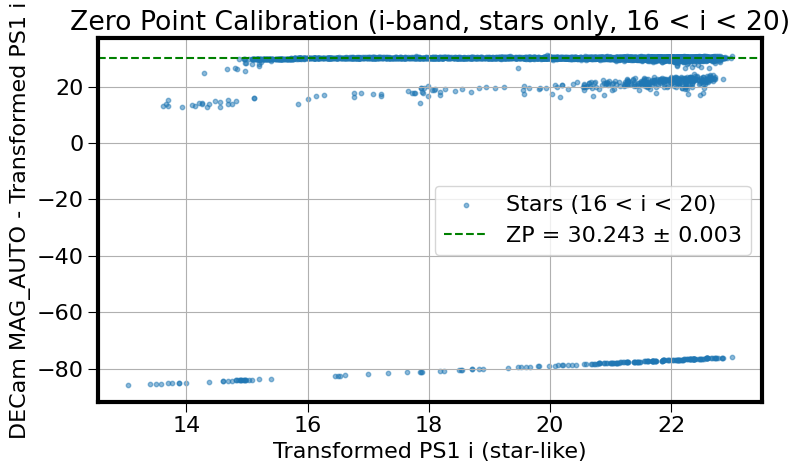

ZP (stars only) = 30.243 ± 0.003


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sigmaclip

# ---------- Read DECam Catalog ----------
def read_decam_catalog(filename):
    with open(filename) as f:
        header = f.readline().strip().split(',')
    return pd.read_csv(filename, skiprows=1, names=header)

# ---------- Read Pan-STARRS Catalog ----------
def read_ps_catalog(filename):
    return pd.read_csv(filename)

# ---------- Star Selection ----------
def is_star_ps1(ps_df, band='i', threshold=0.05):
    """
    Identify stars using PSF - Kron magnitude difference in Pan-STARRS.
    """
    psf_col = f"{band}PSFMag"
    kron_col = f"{band}KronMag"
    #if psf_col not in ps_df.columns or kron_col not in ps_df.columns:
        #raise ValueError(f"Missing columns: {psf_col} or {kron_col}")
    
    delta_mag = ps_df[psf_col] - ps_df[kron_col]
    return np.abs(delta_mag) < threshold

# ---------- Transform PS1 i-band to DECam System ----------
def compute_transformed_z(ps_df):
    z_ps1 = ps_df["zPSFMag"]
    r_ps1 = ps_df["rPSFMag"]
    i_ps1 = ps_df["iPSFMag"]
    return i_ps1 - 0.155 * (r_ps1 - i_ps1) + 0.015

# ---------- Compute Zero Point ----------
def compute_zero_point(decam_df, ps_df):
    mag_decam = decam_df["MAG_APER"].astype(float)
    magerr_decam = decam_df["MAGERR_APER"].astype(float)

    mag_ps_transformed = compute_transformed_z(ps_df)

    # Mask bad PS1 values
    bad_ps_mask = (
        (ps_df["zPSFMag"] > 100) | (ps_df["rPSFMag"] > 100) | (ps_df["iPSFMag"] > 100) |
        (ps_df["zPSFMag"] < -20) | (ps_df["rPSFMag"] < -20) | (ps_df["iPSFMag"] < -20)
    )

    valid = np.isfinite(mag_decam) & np.isfinite(magerr_decam) & np.isfinite(mag_ps_transformed)
    valid &= ~bad_ps_mask

    mag_decam = mag_decam[valid]
    print(mag_decam)
    mag_ps_transformed = mag_ps_transformed[valid]
    #delta_mag = mag_decam - mag_ps_transformed
    delta_mag = mag_ps_transformed - mag_decam
    print(delta_mag)

    # Remove extreme y-axis values (> 60 or < -60)
    y_valid = (delta_mag > 28) & (delta_mag < 60)

    # Apply x-axis range cut: 16 < transformed PS1 i < 20
    x_valid = (mag_ps_transformed > 16.5) & (mag_ps_transformed < 20)

    # Combine both filters
    combined = y_valid & x_valid

    mag_ps_transformed = mag_ps_transformed[combined]
    delta_mag = delta_mag[combined]

    # Sigma clipping
    clipped, _, _ = sigmaclip(delta_mag, low=3, high=3)
    clipped = clipped[~np.isnan(clipped)]
    clipped = clipped[~np.isinf(clipped)]


    zp = np.median(clipped)
    zp_std = np.std(clipped)
    zp_err = zp_std / np.sqrt(len(clipped))

    # Plot
    plt.figure(figsize=(8, 5))
    plt.scatter(mag_ps_transformed, delta_mag, s=10, alpha=0.5, label="Stars (16 < i < 20)")
    plt.axhline(zp, color='g', linestyle='--', label=f'ZP = {zp:.3f} ± {zp_err:.3f}')
    plt.xlabel("Transformed PS1 i (star-like)")
    plt.ylabel("DECam MAG_AUTO - Transformed PS1 i")
    plt.title("Zero Point Calibration (i-band, stars only, 16 < i < 20)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return zp, zp_err


# ---------- Main ----------
decam_path = "/Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/i_band_depth_decam_matched.cat"
ps_path = "/Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/i_band_depth_panstarrs_matched.csv"

decam_df = read_decam_catalog(decam_path)
ps_df = read_ps_catalog(ps_path)

# Select stars only
try:
    star_mask = is_star_ps1(ps_df, band='i', threshold=0.05)
    print(f"Stars selected: {np.sum(star_mask)}")

    decam_df = decam_df[star_mask].reset_index(drop=True)
    ps_df = ps_df[star_mask].reset_index(drop=True)

    if len(decam_df) != len(ps_df):
        print("Warning: Mismatched lengths after star selection.")

    zp, zp_err = compute_zero_point(decam_df, ps_df)
    if not np.isnan(zp):
        print(f"ZP (stars only) = {zp:.3f} ± {zp_err:.3f}")
except Exception as e:
    print(f"Error: {e}")


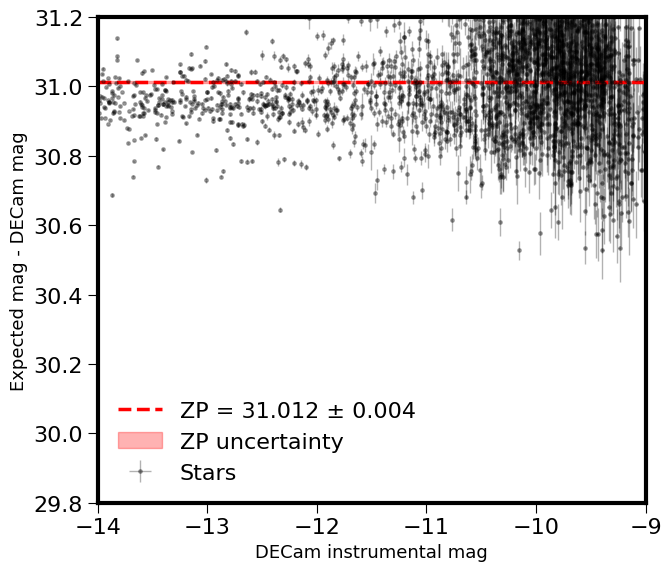

Final ZP = 31.012 ± 0.004


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sigmaclip

# ------------------------------------------------------------
# ---------- Read DECam Catalog ----------
# ------------------------------------------------------------
def read_decam_catalog(filename):
    """Reads DECam catalog with first line as header"""
    with open(filename) as f:
        header = f.readline().strip().split(',')
    return pd.read_csv(filename, skiprows=1, names=header)

# ------------------------------------------------------------
# ---------- Read Pan-STARRS Catalog ----------
# ------------------------------------------------------------
def read_ps_catalog(filename):
    """Reads Pan-STARRS matched catalog (CSV)"""
    return pd.read_csv(filename)

# ------------------------------------------------------------
# ---------- Star Selection ----------
# ------------------------------------------------------------
def is_star_ps1(ps_df, band='i', threshold=0.05):
    """
    Star/galaxy separation using PSF vs Kron magnitude
    threshold ~ 0.05 mag typical for clean star sample
    """
    psf_col = f"{band}PSFMag"
    kron_col = f"{band}KronMag"
    delta_mag = ps_df[psf_col] - ps_df[kron_col]
    return np.abs(delta_mag) < threshold

# ------------------------------------------------------------
# ---------- Transform PS1 magnitudes to DECam system ----------
# ------------------------------------------------------------
def compute_transformed_i(ps_df):
    """
    Transform PS1 mags into DECam i-band system.
    Also propagate PS1 uncertainties.
        i_DECam ≈ i_PS1 - 0.155*(r-i) + 0.015
    """
    r_ps1 = ps_df["rPSFMag"]
    i_ps1 = ps_df["iPSFMag"]
    r_err = ps_df["rPSFMagErr"]
    i_err = ps_df["iPSFMagErr"]

    i_decam = i_ps1 - 0.155 * (r_ps1 - i_ps1) + 0.015

    # Propagate errors: σ^2 = σ_i^2 + (0.155^2)*(σ_r^2 + σ_i^2)
    i_err_conv = np.hypot(i_err, 0.155 * np.hypot(r_err, i_err))

    return i_decam, i_err_conv

# ------------------------------------------------------------
# ---------- Compute Zero Point ----------
# ------------------------------------------------------------
def compute_zero_point(decam_df, ps_df, err_cut=0.1):
    """Compute photometric zeropoint between DECam and PS1 stars"""

    mag_decam = decam_df["MAG_AUTO"].astype(float)
    magerr_decam = decam_df["MAGERR_AUTO"].astype(float)

    mag_ps_transformed, mag_ps_err = compute_transformed_i(ps_df)

    # Remove bad PS1 entries
    bad_ps_mask = (
        (ps_df["zPSFMag"] > 100) | (ps_df["rPSFMag"] > 100) | (ps_df["iPSFMag"] > 100) |
        (ps_df["zPSFMag"] < -20) | (ps_df["rPSFMag"] < -20) | (ps_df["iPSFMag"] < -20)
    )

    valid = np.isfinite(mag_decam) & np.isfinite(magerr_decam) & np.isfinite(mag_ps_transformed)
    valid &= ~bad_ps_mask

    mag_decam = mag_decam[valid]
    magerr_decam = magerr_decam[valid]
    mag_ps_transformed = mag_ps_transformed[valid]
    mag_ps_err = mag_ps_err[valid]

    # Expected – Observed
    delta_mag = mag_ps_transformed - mag_decam

    # Restrict to reasonable ranges
    y_valid = (delta_mag > 28) & (delta_mag < 60)
    x_valid = (mag_decam > -14) & (mag_decam < -9)  # instrumental range
    combined = y_valid & x_valid

    mag_decam = mag_decam[combined]
    magerr_decam = magerr_decam[combined]
    mag_ps_transformed = mag_ps_transformed[combined]
    mag_ps_err = mag_ps_err[combined]
    delta_mag = delta_mag[combined]

    # Total error in Δ (combine DECam + PS1 errors)
    delta_err = np.hypot(magerr_decam, mag_ps_err)

    # Remove stars with very large uncertainties
    good_err = delta_err < err_cut
    mag_decam = mag_decam[good_err]
    magerr_decam = magerr_decam[good_err]
    delta_mag = delta_mag[good_err]
    delta_err = delta_err[good_err]

    # Sigma clipping on Δ
    clipped, low, upp = sigmaclip(delta_mag, low=3, high=3)
    mask_clip = (delta_mag >= low) & (delta_mag <= upp)

    mag_decam = mag_decam[mask_clip]
    magerr_decam = magerr_decam[mask_clip]
    delta_mag = delta_mag[mask_clip]
    delta_err = delta_err[mask_clip]

    # Zeropoint estimate
    zp = np.median(delta_mag)
    zp_std = np.std(delta_mag)
    zp_err = zp_std / np.sqrt(len(delta_mag))

    # ---------- Plot ----------
    fig, ax = plt.subplots(figsize=(7,6))

    # Scatter with error bars
    ax.errorbar(mag_decam, delta_mag,
                xerr=magerr_decam, yerr=delta_err,
                fmt='ko', alpha=0.3, ms=2.5, elinewidth=1.0,
                label="Stars")

    # Zeropoint line + error band
    x_fit = np.linspace(-14, -9, 200)
    ax.plot(x_fit, np.full_like(x_fit, zp), ls='--', color='red', lw=2.5,
            label=f'ZP = {zp:.3f} ± {zp_err:.3f}')
    ax.fill_between(x_fit, zp - zp_err, zp + zp_err,
                    color='red', alpha=0.3, label='ZP uncertainty')

    # Cosmetics
    ax.set_xlim(-14, -9)
    ax.set_ylim(29.8, 31.2)
    ax.set_xlabel("DECam instrumental mag", fontsize=13)
    ax.set_ylabel("Expected mag - DECam mag", fontsize=13)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    return zp, zp_err

# ------------------------------------------------------------
# ------------------ Main Script -----------------------------
# ------------------------------------------------------------
if __name__ == "__main__":
    decam_path = "/Users/aishwarya/Documents/Lyman_alpha/CAT/i_band_decam_matched.cat"
    ps_path = "/Users/aishwarya/Documents/Lyman_alpha/CAT/i_band_panstarrs_matched.csv"

    decam_df = read_decam_catalog(decam_path)
    ps_df = read_ps_catalog(ps_path)

    # Select stars only
    star_mask = is_star_ps1(ps_df, band='i', threshold=0.05)
    decam_df = decam_df[star_mask].reset_index(drop=True)
    ps_df = ps_df[star_mask].reset_index(drop=True)

    zp, zp_err = compute_zero_point(decam_df, ps_df, err_cut=0.1)
    print(f"Final ZP = {zp:.3f} ± {zp_err:.3f}")


FileNotFoundError: [Errno 2] No such file or directory: '/Users/aishwarya/Documents/Lyman_alpha/CAT/decam_image.fits'

Stars selected: 14266


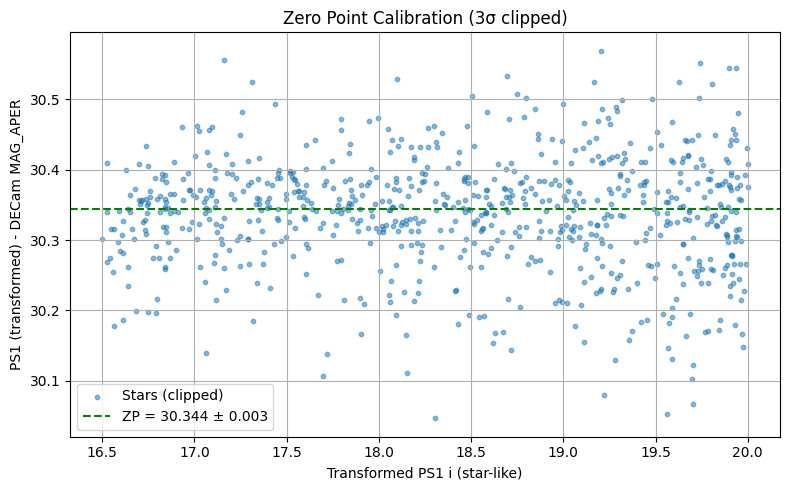

ZP (3σ clipped stars) = 30.344 ± 0.003


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sigmaclip

# ---------- Read DECam Catalog ----------
def read_decam_catalog(filename):
    with open(filename) as f:
        header = f.readline().strip().split(',')
    return pd.read_csv(filename, skiprows=1, names=header)

# ---------- Read Pan-STARRS Catalog ----------
def read_ps_catalog(filename):
    return pd.read_csv(filename)

# ---------- Star Selection ----------
def is_star_ps1(ps_df, band='i', threshold=0.05):
    """Identify stars using PSF - Kron magnitude difference in Pan-STARRS."""
    psf_col = f"{band}PSFMag"
    kron_col = f"{band}KronMag"
    delta_mag = ps_df[psf_col] - ps_df[kron_col]
    return np.abs(delta_mag) < threshold

# ---------- Transform PS1 i-band to DECam System ----------
def compute_transformed_z(ps_df):
    z_ps1 = ps_df["zPSFMag"]
    r_ps1 = ps_df["rPSFMag"]
    i_ps1 = ps_df["iPSFMag"]
    return i_ps1 - 0.155 * (r_ps1 - i_ps1) + 0.015

# ---------- Compute Zero Point with full 3σ clipping ----------
def compute_zero_point(decam_df, ps_df):
    mag_decam = decam_df["MAG_APER"].astype(float)
    magerr_decam = decam_df["MAGERR_APER"].astype(float)

    mag_ps_transformed = compute_transformed_z(ps_df)

    # Mask bad PS1 values
    bad_ps_mask = (
        (ps_df["zPSFMag"] > 100) | (ps_df["rPSFMag"] > 100) | (ps_df["iPSFMag"] > 100) |
        (ps_df["zPSFMag"] < -20) | (ps_df["rPSFMag"] < -20) | (ps_df["iPSFMag"] < -20)
    )

    valid = np.isfinite(mag_decam) & np.isfinite(magerr_decam) & np.isfinite(mag_ps_transformed)
    valid &= ~bad_ps_mask

    mag_decam = mag_decam[valid]
    mag_ps_transformed = mag_ps_transformed[valid]

    # Compute Δmag
    delta_mag = mag_ps_transformed - mag_decam

    # Initial cuts
    y_valid = (delta_mag > 28) & (delta_mag < 60)
    x_valid = (mag_ps_transformed > 16.5) & (mag_ps_transformed < 20)
    combined = y_valid & x_valid

    mag_ps_transformed = mag_ps_transformed[combined]
    delta_mag = delta_mag[combined]

    # ---- 3σ clipping applied iteratively ----
    # Clip delta_mag
    delta_mag_clipped, low, high = sigmaclip(delta_mag, low=5, high=5)
    mask_y = (delta_mag >= low) & (delta_mag <= high)

    mag_ps_transformed = mag_ps_transformed[mask_y]
    delta_mag = delta_mag[mask_y]

    # Clip again in mag_ps_transformed if desired
    mag_ps_clipped, low_x, high_x = sigmaclip(mag_ps_transformed, low=5, high=5)
    mask_x = (mag_ps_transformed >= low_x) & (mag_ps_transformed <= high_x)

    mag_ps_transformed = mag_ps_transformed[mask_x]
    delta_mag = delta_mag[mask_x]

    # Final Zero Point
    zp = np.median(delta_mag)
    zp_std = np.std(delta_mag)
    zp_err = zp_std / np.sqrt(len(delta_mag))

    # ---- Plot ----
    plt.figure(figsize=(8, 5))
    plt.scatter(mag_ps_transformed, delta_mag, s=10, alpha=0.5, label="Stars (clipped)")
    plt.axhline(zp, color='g', linestyle='--', label=f'ZP = {zp:.3f} ± {zp_err:.3f}')
    plt.xlabel("Transformed PS1 i (star-like)")
    plt.ylabel("PS1 (transformed) - DECam MAG_APER")
    plt.title("Zero Point Calibration (3σ clipped)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return zp, zp_err

# ---------- Main ----------
decam_path = "/Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/i_band_depth_decam_matched.cat"
ps_path = "/Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/i_band_depth_panstarrs_matched.csv"

decam_df = read_decam_catalog(decam_path)
ps_df = read_ps_catalog(ps_path)

try:
    star_mask = is_star_ps1(ps_df, band='i', threshold=0.05)
    print(f"Stars selected: {np.sum(star_mask)}")

    decam_df = decam_df[star_mask].reset_index(drop=True)
    ps_df = ps_df[star_mask].reset_index(drop=True)

    if len(decam_df) != len(ps_df):
        print("Warning: Mismatched lengths after star selection.")

    zp, zp_err = compute_zero_point(decam_df, ps_df)
    if not np.isnan(zp):
        print(f"ZP (3σ clipped stars) = {zp:.3f} ± {zp_err:.3f}")
except Exception as e:
    print(f"Error: {e}")


DAOStarFinder detected 146179 sources in the DECam image.


ValueError: 'xerr' (shape: (26985,)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'x' (shape: (26356,))

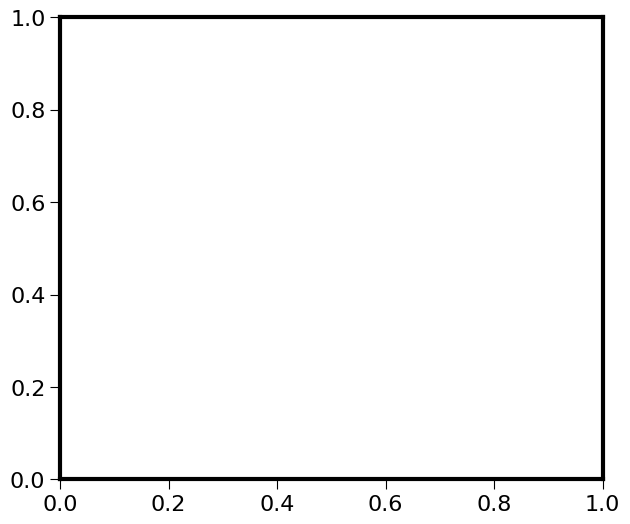

In [38]:
print(decam_df.columns)
print(decam_df["MAG_APER"].head())
print(decam_df["MAGERR_APER"].head())


Index(['NUMBER', 'X_IMAGE', 'Y_IMAGE', 'ALPHA_J2000', 'DELTA_J2000',
       'MAG_APER', 'MAGERR_APER', 'MAG_AUTO', 'MAGERR_AUTO', 'FLAGS',
       'RA_CORRECTED', 'DEC_CORRECTED'],
      dtype='object')
0   -5.4662
1   -6.0559
2   -9.4657
3   -9.0310
4   -8.5301
Name: MAG_APER, dtype: float64
0    0.1529
1    0.0886
2    0.0036
3    0.0051
4    0.0090
Name: MAGERR_APER, dtype: float64


In [52]:
#!/usr/bin/env python3
"""
Zero point from DECam detections cross-matched to Pan-STARRS (no pre-matched catalogs).
Reproduces the "Δmag vs DECam instrumental mag" plot with horizontal median ZP line.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from astropy.table import Table, Column
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u

from photutils.detection import DAOStarFinder
from scipy.stats import sigmaclip


# ----------------------------- Utilities -----------------------------

def _pick_ps1_cols(ps_df):
    """
    Accept either *PSFMag or *MeanPSFMag PS1 columns and return a uniform mapping.
    Returns a dict with keys: r, i, rerr, ierr, ra, dec
    Raises KeyError if required columns are missing.
    """
    # magnitude columns (prefer PSFMag names if both exist)
    r_col  = "rPSFMag"       if "rPSFMag"       in ps_df.columns else "rMeanPSFMag"
    i_col  = "iPSFMag"       if "iPSFMag"       in ps_df.columns else "iMeanPSFMag"
    re_col = "rPSFMagErr"    if "rPSFMagErr"    in ps_df.columns else "rMeanPSFMagErr"
    ie_col = "iPSFMagErr"    if "iPSFMagErr"    in ps_df.columns else "iMeanPSFMagErr"

    # sky coords (accept common variants)
    ra_cand  = [c for c in ["raMean", "RA", "ra"]  if c in ps_df.columns]
    dec_cand = [c for c in ["decMean", "Dec", "dec"] if c in ps_df.columns]
    if not ra_cand or not dec_cand:
        raise KeyError("PS1 table must contain RA/Dec columns (e.g. raMean/decMean).")

    need = [r_col, i_col, re_col, ie_col]
    miss = [c for c in need if c not in ps_df.columns]
    if miss:
        raise KeyError(f"PS1 table missing required columns: {miss}")

    return dict(r=r_col, i=i_col, rerr=re_col, ierr=ie_col, ra=ra_cand[0], dec=dec_cand[0])


def compute_transformed_i(ps_df):
    """
    Transform PS1 i → DECam i using DES DR2 recipe:
      i_DECam = i_PS1 - 0.155*(r_PS1 - i_PS1) + 0.015
      σ^2 = σ_i^2 + (0.155^2)*(σ_r^2 + σ_i^2)
    Accepts PS1 *PSFMag or *MeanPSFMag columns transparently.
    """
    cols = _pick_ps1_cols(ps_df)
    r_ps1 = ps_df[cols["r"]].astype(float).to_numpy()
    i_ps1 = ps_df[cols["i"]].astype(float).to_numpy()
    r_err = ps_df[cols["rerr"]].astype(float).to_numpy()
    i_err = ps_df[cols["ierr"]].astype(float).to_numpy()

    i_decam = i_ps1 - 0.155*(r_ps1 - i_ps1) + 0.015
    i_err_decam = np.sqrt(i_err**2 + (0.155**2)*(r_err**2 + i_err**2))
    return i_decam, i_err_decam


def find_stars_single(hdu, fwhm=5, threshold_factor=20):
    """
    Run DAOStarFinder on an image HDU and return an astropy Table with
    x,y, flux, npix and RA/Dec columns (using the HDU WCS).
    """
    data = hdu.data
    hdr  = hdu.header
    # robust background statistics
    _, median, std = sigma_clipped_stats(data, sigma=3.0)
    # detect
    daofind = DAOStarFinder(fwhm=fwhm, threshold=threshold_factor*std)
    sources = daofind(data - median)
    if sources is None or len(sources) == 0:
        return Table()  # empty

    # WCS → sky coords
    wcs = WCS(hdr)
    x = np.array(sources['xcentroid'])
    y = np.array(sources['ycentroid'])
    ra, dec = wcs.pixel_to_world_values(x, y)

    sources.add_columns([
        Column(name="RA",  data=ra),
        Column(name="Dec", data=dec),
    ])

    # Attach a crude flux error estimate for instrumental mag errors:
    # σ_F ≈ sqrt( F/gain + npix * σ_sky^2 ) ;  magerr ≈ 1.0857 * σ_F / F
    # Try to read gain from header; default to 1.0 e-/ADU if absent.
    # Note: npix from DAOStarFinder is the "footprint" size at threshold, used as an area proxy.
    gain_keys = [k for k in ["GAIN", "GAINA", "GAIN1"] if k in hdr]
    gain = float(hdr[gain_keys[0]]) if gain_keys else 1.0
    npix = np.array(sources["npix"], dtype=float)
    flux = np.array(sources["flux"], dtype=float)
    sigma_sky = float(std)

    flux_err = np.sqrt(np.clip(flux, 0, None)/gain + npix*(sigma_sky**2))
    sources.add_column(Column(name="flux_err", data=flux_err))

    return sources


def instrumental_mag_from_flux(flux, flux_err):
    """Instrumental mag and error from flux."""
    flux = np.asarray(flux, dtype=float)
    flux_err = np.asarray(flux_err, dtype=float)
    good = (flux > 0) & np.isfinite(flux) & np.isfinite(flux_err)
    mag = np.full_like(flux, np.nan, dtype=float)
    magerr = np.full_like(flux_err, np.nan, dtype=float)
    mag[good] = -2.5 * np.log10(flux[good])
    magerr[good] = 1.0857 * (flux_err[good] / flux[good])
    return mag, magerr


def cross_match(decam_tab, ps_df, radius=1.0*u.arcsec):
    """Nearest-neighbor sky match between DAO detections and PS1 table."""
    cols = _pick_ps1_cols(ps_df)
    c_dec = SkyCoord(ra=decam_tab["RA"]*u.deg,  dec=decam_tab["Dec"]*u.deg)
    c_ps  = SkyCoord(ra=ps_df[cols["ra"]].to_numpy()*u.deg,
                     dec=ps_df[cols["dec"]].to_numpy()*u.deg)
    idx, sep, _ = c_dec.match_to_catalog_sky(c_ps)
    keep = sep < radius
    return keep, idx[keep]


def compute_zero_point_from_matches(decam_tab, ps_df, err_cut=0.1, match_radius=1.0*u.arcsec,
                                    make_plot=True, out_png=None):
    """
    Compute ZP as the **median of Δmag** with an error from std/√N,
    after error cut on total uncertainty and 3σ clipping on Δmag.
    """
    # match
    keep, cat_idx = cross_match(decam_tab, ps_df, radius=match_radius)
    if np.count_nonzero(keep) == 0:
        raise ValueError("No DAO↔PS1 matches within the given radius.")

    dao = decam_tab[keep]
    ps1 = ps_df.iloc[cat_idx].reset_index(drop=True)

    # DECam instrumental mags (from DAO flux)
    mag_decam, magerr_decam = instrumental_mag_from_flux(dao["flux"], dao["flux_err"])

    # PS1 transformed i (→ DECam system)
    mag_ps, mag_ps_err = compute_transformed_i(ps1)

    # Build Δmag and total error; mask invalid
    valid = np.isfinite(mag_decam) & np.isfinite(magerr_decam) \
          & np.isfinite(mag_ps)    & np.isfinite(mag_ps_err)
    mag_decam   = mag_decam[valid]
    magerr_decam= magerr_decam[valid]
    mag_ps      = mag_ps[valid]
    mag_ps_err  = mag_ps_err[valid]

    if mag_decam.size == 0:
        raise ValueError("No valid stars after NaN filtering.")

    delta = mag_ps - mag_decam
    delta_err = np.hypot(mag_ps_err, magerr_decam)

    # your error cut
    good = delta_err < err_cut
    mag_decam   = mag_decam[good]
    magerr_decam= magerr_decam[good]
    delta       = delta[good]
    delta_err   = delta_err[good]

    if delta.size == 0:
        raise ValueError("No stars left after error cut; relax err_cut.")

    # 3σ-clip on Δmag
    _, lo, hi = sigmaclip(delta, low=3, high=3)
    clip = (delta >= lo) & (delta <= hi)
    mag_decam, magerr_decam, delta, delta_err = \
        mag_decam[clip], magerr_decam[clip], delta[clip], delta_err[clip]

    if delta.size == 0:
        raise ValueError("No stars left after sigma clipping.")

    # ZP = median(Δmag)
    zp = float(np.median(delta))
    zp_std = float(np.std(delta, ddof=1)) if delta.size > 1 else 0.0
    zp_err = zp_std/np.sqrt(delta.size) if delta.size > 0 else np.nan

    # Plot (like your first script)
    if make_plot:
        fig, ax = plt.subplots(figsize=(7, 6))
        ax.errorbar(
            mag_decam, delta,
            xerr=magerr_decam, yerr=delta_err,
            fmt='o', ms=2.5, alpha=0.35, elinewidth=1.0, capsize=0, color='k',
            label=f"N = {delta.size}"
        )
        xs = np.linspace(np.min(mag_decam), np.max(mag_decam), 200)
        ax.plot(xs, np.full_like(xs, zp), ls='--', color='red', lw=2.0,
                label=f'ZP = {zp:.3f} ± {zp_err:.3f}')
        ax.fill_between(xs, zp - zp_err, zp + zp_err, color='red', alpha=0.25,
                        label='ZP uncertainty')

        ax.set_xlabel("DECam instrumental mag (from DAO flux)", fontsize=12)
        ax.set_ylabel("Transformed PS1 mag − DECam mag", fontsize=12)
        ax.legend(frameon=False)
        plt.tight_layout()
        if out_png:
            plt.savefig(out_png, dpi=160)
        plt.show()

    return zp, zp_err, delta.size


# ------------------------------ Main -------------------------------

if __name__ == "__main__":
    # --- inputs (EDIT THESE) ---
    fits_file = "/Users/aishwarya/Documents/Lyman_alpha/I/mosaic_i_cut.fits"
    ps1_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/Pannstar_casjobs.csv"

    # --- load data ---
    with fits.open(fits_file) as hdul:
        hdu = hdul[0]
        dao_sources = find_stars_single(hdu, fwhm=5, threshold_factor=20)
    print(f"DAOStarFinder detections: {len(dao_sources)}")

    ps_df = pd.read_csv(ps1_csv)

    # --- compute zero point (err_cut, match radius tunable) ---
    zp, zp_err, n_used = compute_zero_point_from_matches(
        dao_sources, ps_df, err_cut=0.1, match_radius=1.0*u.arcsec,
        make_plot=True, out_png=None
    )
    print(f"Final i-band ZP = {zp:.3f} ± {zp_err:.3f}  (N={n_used})")


DAOStarFinder detections: 146179


FileNotFoundError: [Errno 2] No such file or directory: '/path/to/your/PANSTARRS_i.csv'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sigmaclip
from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma

# ---------- Read DECam Catalog ----------
def read_decam_catalog(filename):
    with open(filename) as f:
        header = f.readline().strip().split(',')
    return pd.read_csv(filename, skiprows=1, names=header)

# ---------- Read Pan-STARRS Catalog ----------
def read_ps_catalog(filename):
    return pd.read_csv(filename)

# ---------- Star Selection ----------
def is_star_ps1(ps_df, band='i', threshold=0.05):
    psf_col = f"{band}PSFMag"
    kron_col = f"{band}KronMag"
    if psf_col not in ps_df.columns or kron_col not in ps_df.columns:
        raise ValueError(f"Missing columns: {psf_col} or {kron_col}")
    
    delta_mag = ps_df[psf_col] - ps_df[kron_col]
    return np.abs(delta_mag) < threshold

# ---------- PS1 → DECam i-band Transformation ----------
def compute_transformed_i(ps_df):
    z_ps1 = ps_df["zPSFMag"]
    r_ps1 = ps_df["rPSFMag"]
    i_ps1 = ps_df["iPSFMag"]
    return i_ps1 - 0.155 * (r_ps1 - i_ps1) + 0.015

# ---------- K-correction using PSF profile ----------
def gaussian(x_array: np.ndarray, mean: float, fwhm: float):
    sig = fwhm * gaussian_fwhm_to_sigma
    return np.exp(-np.power(x_array - mean, 2.0) / (2 * sig**2))

def calculate_k_constant(aperture_radius: float, seeing: float):
    infinite_integral = quad(gaussian, 0, np.inf, args=(0, seeing))[0]
    definite_integral = quad(gaussian, 0, aperture_radius, args=(0, seeing))[0]
    constant = infinite_integral / definite_integral
    return constant

def calculate_k_constant_mag(aperture_radius: float, seeing: float) -> float:
    k_constant = calculate_k_constant(aperture_radius, seeing)
    return -2.5 * np.log10(k_constant)

# ---------- Compute Zero Point and Corrected ZP' ----------
def compute_zero_point(decam_df, ps_df, aperture_radius=1.0, seeing=1.2):
    mag_decam = decam_df["MAG_AUTO"].astype(float)
    magerr_decam = decam_df["MAGERR_AUTO"].astype(float)
    mag_ps_transformed = compute_transformed_i(ps_df)

    # Mask bad values
    bad_ps_mask = (
        (ps_df["zPSFMag"] > 100) | (ps_df["rPSFMag"] > 100) | (ps_df["iPSFMag"] > 100) |
        (ps_df["zPSFMag"] < -20) | (ps_df["rPSFMag"] < -20) | (ps_df["iPSFMag"] < -20)
    )
    valid = np.isfinite(mag_decam) & np.isfinite(magerr_decam) & np.isfinite(mag_ps_transformed)
    valid &= ~bad_ps_mask

    mag_decam = mag_decam[valid]
    mag_ps_transformed = mag_ps_transformed[valid]

    # delta_mag = PS1_transformed - DECam
    delta_mag = mag_ps_transformed - mag_decam

    # Clip Y-axis and X-axis
    y_valid = (delta_mag > 28) & (delta_mag < 60)
    x_valid = (mag_ps_transformed > 16) & (mag_ps_transformed < 20)
    combined = y_valid & x_valid

    mag_ps_transformed = mag_ps_transformed[combined]
    delta_mag = delta_mag[combined]

    # Sigma clipping
    clipped, _, _ = sigmaclip(delta_mag, low=3, high=3)
    clipped = clipped[~np.isnan(clipped) & ~np.isinf(clipped)]

    zp = np.median(clipped)
    zp_std = np.std(clipped)
    zp_err = zp_std / np.sqrt(len(clipped))

    # Apply k-correction using Gaussian PSF integration
    k_mag = calculate_k_constant_mag(aperture_radius, seeing)
    zp_prime = zp - k_mag

    # Plot
    plt.figure(figsize=(8, 5))
    plt.scatter(mag_ps_transformed, delta_mag, s=10, alpha=0.5, label="Stars (16 < i < 20)")
    plt.axhline(zp, color='green', linestyle='--', label=f'ZP = {zp:.3f} ± {zp_err:.3f}')
    plt.axhline(zp_prime, color='blue', linestyle='-.', label=f"ZP′ = {zp_prime:.3f} (corrected)")
    plt.xlabel("Transformed PS1 i (star-like)")
    plt.ylabel("Transformed PS1 i − DECam MAG_AUTO")
    plt.title("Zero Point Calibration (i-band)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return zp, zp_err, zp_prime, k_mag

# ---------- Main ----------
if __name__ == "__main__":
    # Set parameters
    SEEING_I = 1.17
    SEEING_Z = 1.23
    APERTURE_RADIUS = 1.0

    decam_path = "/Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/i_band_depth_decam_matched.cat"
    ps_path = "/Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/i_band_depth_panstarrs_matched.csv"

    decam_df = read_decam_catalog(decam_path)
    ps_df = read_ps_catalog(ps_path)

    try:
        star_mask = is_star_ps1(ps_df, band='i', threshold=0.05)
        print(f"Stars selected: {np.sum(star_mask)}")

        decam_df = decam_df[star_mask].reset_index(drop=True)
        ps_df = ps_df[star_mask].reset_index(drop=True)

        if len(decam_df) != len(ps_df):
            print("Warning: DECam and PS1 catalogs not aligned.")

        zp, zp_err, zp_prime, k_mag = compute_zero_point(
            decam_df, ps_df,
            aperture_radius=APERTURE_RADIUS,
            seeing=SEEING_I
        )
        if not np.isnan(zp):
            print(f"\nZP = {zp:.3f} ± {zp_err:.3f}")
            print(f"k-correction = {k_mag:.3f}")
            print(f"ZP′ (corrected) = {zp_prime:.3f}")
    except Exception as e:
        print(f" Error: {e}")


Stars selected: 13759


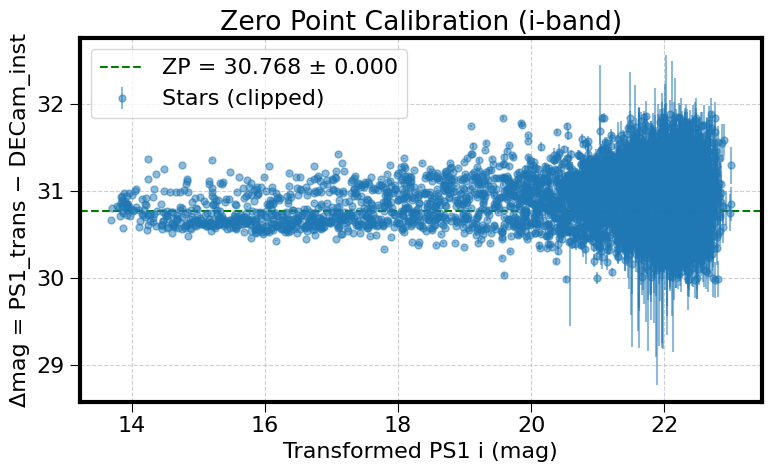

ZP (stars only) = 30.768 ± 0.000


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sigmaclip

# ---------- Read DECam Catalog ----------
def read_decam_catalog(filename):
    with open(filename) as f:
        header = f.readline().strip().split(',')
    return pd.read_csv(filename, skiprows=1, names=header)

# ---------- Read Pan-STARRS Catalog ----------
def read_ps_catalog(filename):
    return pd.read_csv(filename)

# ---------- Star Selection ----------
def is_star_ps1(ps_df, band='i', threshold=0.05):
    """
    Identify stars using PSF - Kron magnitude difference in Pan-STARRS.
    """
    psf_col = f"{band}PSFMag"
    kron_col = f"{band}KronMag"
    if psf_col not in ps_df.columns or kron_col not in ps_df.columns:
        raise ValueError(f"Missing columns: {psf_col} or {kron_col}")
    
    delta_mag = ps_df[psf_col] - ps_df[kron_col]
    return np.abs(delta_mag) < threshold

# ---------- Transform PS1 i-band to DECam System (including error propagation) ----------
def compute_transformed_i_with_error(ps_df):
    i_ps1 = ps_df["iPSFMag"]
    r_ps1 = ps_df["rPSFMag"]
    i_err = ps_df["iPSFMagErr"]
    r_err = ps_df["rPSFMagErr"]

    # Mask invalid mags/errors (e.g. -999 or >100)
    valid_mask = (
        (i_ps1 > -90) & (i_ps1 < 100) &
        (r_ps1 > -90) & (r_ps1 < 100) &
        (i_err > 0) & (i_err < 10) &
        (r_err > 0) & (r_err < 10)
    )
    
    i_ps1_valid = i_ps1[valid_mask]
    r_ps1_valid = r_ps1[valid_mask]
    i_err_valid = i_err[valid_mask]
    r_err_valid = r_err[valid_mask]

    # Transformation
    i_decam = i_ps1_valid - 0.155 * (r_ps1_valid - i_ps1_valid) + 0.015

    # Propagate errors
    converted_i_uncertainties = np.hypot(
        i_err_valid, 0.155 * np.hypot(i_err_valid, r_err_valid)
    )

    return i_decam, converted_i_uncertainties, valid_mask

# ---------- Compute Zero Point ----------
def compute_zero_point(decam_df, ps_df):
    # DECam instrumental mags
    mag_decam = decam_df["MAG_AUTO"].astype(float)
    magerr_decam = decam_df["MAGERR_AUTO"].astype(float)

    # Transformed PS1 mags & errors
    mag_ps_transformed, mag_ps_err, valid_mask_ps = compute_transformed_i_with_error(ps_df)

    # Apply PS mask to DECam
    mag_decam = mag_decam[valid_mask_ps]
    magerr_decam = magerr_decam[valid_mask_ps]

    # Validity cuts
    valid = (
        np.isfinite(mag_decam) & np.isfinite(magerr_decam) &
        np.isfinite(mag_ps_transformed) & np.isfinite(mag_ps_err) &
        (magerr_decam > 0) & (magerr_decam < 10) &
        (mag_ps_err > 0) & (mag_ps_err < 10)
    )
    mag_decam = mag_decam[valid]
    magerr_decam = magerr_decam[valid]
    mag_ps_transformed = mag_ps_transformed[valid]
    mag_ps_err = mag_ps_err[valid]

    # Δmag = (PS1→DECam) − (DECam instrumental)
    delta_mag = mag_ps_transformed - mag_decam
    delta_err = np.hypot(mag_ps_err, magerr_decam)   # <-- CORRECT per-star uncertainty

    # Sigma clipping
    clipped, lower, upper = sigmaclip(delta_mag, low=3, high=3)
    mask_clip = (delta_mag >= lower) & (delta_mag <= upper)
    delta_mag = delta_mag[mask_clip]
    delta_err = delta_err[mask_clip]
    mag_ps_transformed = mag_ps_transformed[mask_clip]

    if len(delta_mag) == 0:
        raise ValueError("No valid stars after clipping.")

    # Weighted zero point
    weights = 1.0 / (delta_err**2)
    zp = np.sum(delta_mag * weights) / np.sum(weights)
    zp_err = np.sqrt(1.0 / np.sum(weights))  # proper weighted uncertainty

    # Plot
    plt.figure(figsize=(8, 5))
    plt.errorbar(
        mag_ps_transformed, delta_mag,
        yerr=delta_err,
        fmt='o', ms=5, alpha=0.5, label='Stars (clipped)'
    )
    plt.axhline(zp, color='g', linestyle='--', label=f'ZP = {zp:.3f} ± {zp_err:.3f}')
    plt.xlabel("Transformed PS1 i (mag)")
    plt.ylabel("Δmag = PS1_trans − DECam_inst")
    plt.title("Zero Point Calibration (i-band)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return zp, zp_err



# ---------- Main ----------
decam_path = "/Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/z_band_depth_decam_matched.cat"
ps_path = "/Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/z_band_depth_panstarrs_matched.csv"

decam_df = read_decam_catalog(decam_path)
ps_df = read_ps_catalog(ps_path)

# Select stars only
try:
    star_mask = is_star_ps1(ps_df, band='i', threshold=0.05)
    print(f"Stars selected: {np.sum(star_mask)}")

    decam_df = decam_df[star_mask].reset_index(drop=True)
    ps_df = ps_df[star_mask].reset_index(drop=True)

    if len(decam_df) != len(ps_df):
        print("Warning: Star catalogs not aligned row-wise.")

    zp, zp_err = compute_zero_point(decam_df, ps_df)
    if not np.isnan(zp):
        print(f"ZP (stars only) = {zp:.3f} ± {zp_err:.3f}")
except Exception as e:
    print(f"Error: {e}")


In [ ]:
--- Processing file: z_band_depth ---
Median RA Offset: -0.017 arcsec
Median Dec Offset: 0.064 arcsec
Saved matched DECam to: /Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/z_band_depth_decam_matched.cat
Saved matched Pan-STARRS to: /Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/z_band_depth_panstarrs_matched.csv



--- i-band ---
i-band: stars selected = 9263
i-band ZP = 30.700 ± 0.003


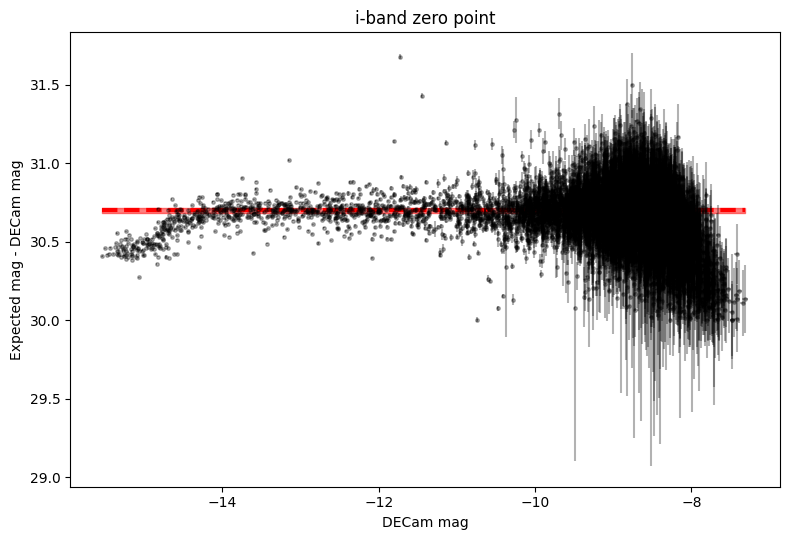


--- z-band ---
z-band: stars selected = 9107
z-band ZP = 30.214 ± 0.007


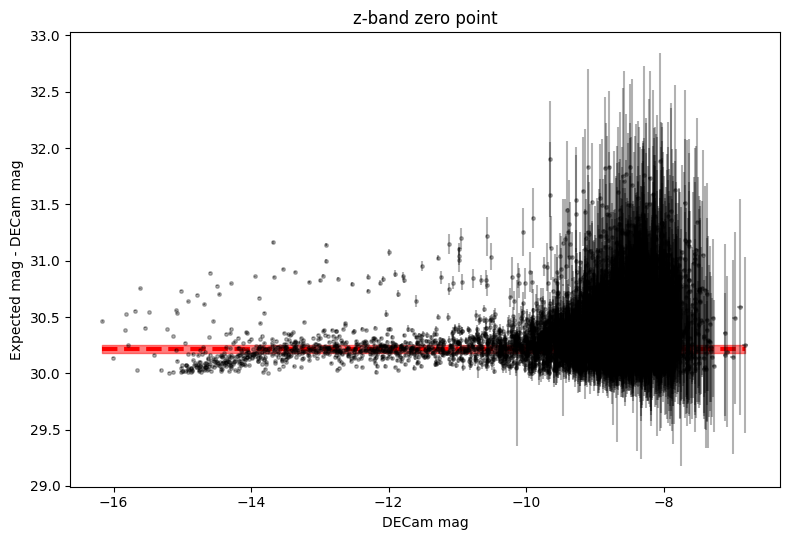

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from numpy.typing import ArrayLike

# ---------- Read DECam Catalog ----------
def read_decam_catalog(filename: str) -> pd.DataFrame:
    with open(filename) as f:
        header = f.readline().strip().split(',')
    return pd.read_csv(filename, skiprows=1, names=header)

# ---------- Read Pan-STARRS Catalog ----------
def read_ps_catalog(filename: str) -> pd.DataFrame:
    return pd.read_csv(filename)

# ---------- Star Selection (i-band morphology) ----------
def is_star_ps1(ps_df: pd.DataFrame, band: str = 'i', threshold: float = 0.05) -> ArrayLike:
    psf_col = f"{band}PSFMag"
    kron_col = f"{band}KronMag"
    if psf_col not in ps_df.columns or kron_col not in ps_df.columns:
        raise ValueError(f"Missing columns: {psf_col} or {kron_col}")
    delta_mag = ps_df[psf_col] - ps_df[kron_col]
    return np.abs(delta_mag.values) < threshold

# ---------- Robust PS1 → DECam transforms with propagated uncertainties ----------
def _col(ps: pd.DataFrame, base: str, kind: str = "mag") -> np.ndarray:
    """
    Get PS1 column robustly.
    Tries PSFMag and MeanPSFMag variants (and *Err).
    kind = "mag" or "err".
    """
    if kind == "mag":
        candidates = [f"{base}PSFMag", f"{base}MeanPSFMag"]
    else:
        candidates = [f"{base}PSFMagErr", f"{base}MeanPSFMagErr"]

    for c in candidates:
        if c in ps.columns:
            return ps[c].values.astype(float)

    # fallback
    if kind == "mag":
        raise KeyError(f"No PS1 mag column found for {base}")
    return np.full(len(ps), 0.02, dtype=float)  # 0.02 mag default error floor

def convert_panstars_i_dec_mags(ps: pd.DataFrame):
    rPSF = _col(ps, 'r', 'mag'); iPSF = _col(ps, 'i', 'mag')
    rErr = _col(ps, 'r', 'err'); iErr = _col(ps, 'i', 'err')
    # Transform
    i_dec = iPSF - 0.155 * (rPSF - iPSF) + 0.015
    i_dec_err = np.hypot(iErr, 0.155 * np.hypot(iErr, rErr))
    return i_dec, i_dec_err

def convert_panstars_z_dec_mags(ps: pd.DataFrame):
    rPSF = _col(ps, 'r', 'mag'); iPSF = _col(ps, 'i', 'mag'); zPSF = _col(ps, 'z', 'mag')
    rErr = _col(ps, 'r', 'err'); iErr = _col(ps, 'i', 'err'); zErr = _col(ps, 'z', 'err')
    # Transform
    z_dec = zPSF - 0.114 * (rPSF - iPSF) - 0.010
    z_dec_err = np.hypot(zErr, 0.114 * np.hypot(iErr, rErr))
    return z_dec, z_dec_err

# ---------- Straight line model ----------
def straight_line(x_array: np.ndarray, intercept: float):
    return x_array + intercept

# ---------- Pipeline ----------
def prepare_mags(decam_df: pd.DataFrame, ps_df: pd.DataFrame, band: str):
    dec_mags = decam_df['MAG_APER'].values.astype(float)
    dec_errs = decam_df['MAGERR_APER'].values.astype(float)
    if band == 'i':
        exp_mags, exp_errs = convert_panstars_i_dec_mags(ps_df)
    elif band == 'z':
        exp_mags, exp_errs = convert_panstars_z_dec_mags(ps_df)
    else:
        raise ValueError("band must be 'i' or 'z'.")
    return dec_mags, dec_errs, exp_mags, exp_errs

def apply_broadband_cuts(dec_mags, dec_errs, exp_mags, exp_errs):
    diffs = exp_mags - dec_mags
    diff_cut = np.where((diffs > 30) & (diffs < 32))[0]
    good_values = np.where(exp_mags < 100)[0]
    other_good_values = np.where(dec_mags < -6)[0]
    more_good_values = np.where(exp_errs < 1.0)[0]
    even_more = np.where(dec_errs < 1.0)[0]

    idx = np.intersect1d(good_values, other_good_values)
    idx = np.intersect1d(idx, more_good_values)
    idx = np.intersect1d(idx, diff_cut)
    idx = np.intersect1d(idx, even_more)

    return dec_mags[idx], dec_errs[idx], exp_mags[idx], exp_errs[idx]

def fit_zero_point(dec_mags, exp_mags, exp_errs):
    """
    Fit y = x + c with slope fixed to 1.
    Estimate ZP as median residual,
    and error from scatter / sqrt(N).
    """
    fit_sel = np.where((dec_mags > -14) & (dec_mags < -11))[0]
    if len(fit_sel) < 3:
        raise RuntimeError("Not enough points in the fitting range (-14 < DECam < -11) to fit ZP.")
    
    # Residuals = (expected - measured)
    residuals = exp_mags[fit_sel] - dec_mags[fit_sel]
    
    # Zero point = median of residuals
    zpt = np.median(residuals)
    
    # Error = scatter / sqrt(N)
    scatter = np.std(residuals)
    zpt_err = scatter / np.sqrt(len(residuals))
    
    return zpt, zpt_err


def plot_zpt(dec_mags, dec_errs, exp_mags, exp_errs, band: str, zpt: float, zpt_err: float):
    y = exp_mags - dec_mags
    y_err = np.hypot(dec_errs, exp_errs)
    good = np.where(y_err < 1e5)[0]

    nstd = 5.0
    up = zpt + nstd * zpt_err
    dw = zpt - nstd * zpt_err
    x_fit = np.linspace(np.sort(dec_mags)[0], np.sort(dec_mags)[-1], 200)

    plt.figure(figsize=(8, 5.5))
    plt.errorbar(
        dec_mags[good], y[good],
        xerr=dec_errs[good], yerr=y_err[good],
        fmt='ko', alpha=0.3, ms=2.5, elinewidth=1.5
    )
    plt.plot(x_fit, zpt * np.ones_like(x_fit), ls='--', color='r', lw=3, zorder=1)
    plt.fill_between(x_fit, up, dw, alpha=.5, color='r')

    plt.xlabel('DECam mag')
    plt.ylabel('Expected mag - DECam mag')
    plt.title(f'{band}-band zero point')
    plt.tight_layout()
    plt.show()

def run_band(decam_path: str, ps_path: str, band: str):
    decam_df = read_decam_catalog(decam_path)
    ps_df = read_ps_catalog(ps_path)

    # star-like
    star_mask = is_star_ps1(ps_df, band='i', threshold=0.05)
    decam_df = decam_df[star_mask].reset_index(drop=True)
    ps_df = ps_df[star_mask].reset_index(drop=True)
    print(f"{band}-band: stars selected = {len(decam_df)}")

    dec_mags, dec_errs, exp_mags, exp_errs = prepare_mags(decam_df, ps_df, band=band)
    dec_mags, dec_errs, exp_mags, exp_errs = apply_broadband_cuts(dec_mags, dec_errs, exp_mags, exp_errs)

    if len(dec_mags) < 3:
        raise RuntimeError(f"After cuts, not enough points to fit for {band}-band.")

    zpt, zpt_err = fit_zero_point(dec_mags, exp_mags, exp_errs)
    print(f"{band}-band ZP = {zpt:.3f} ± {zpt_err:.3f}")

    plot_zpt(dec_mags, dec_errs, exp_mags, exp_errs, band, zpt, zpt_err)
    return zpt, zpt_err

# ---------- Main ----------
if __name__ == "__main__":
    I_DECam = "/Users/aishwarya/Documents/Lyman_alpha/Matched/matched_cat/i_band_depth_decam_matched.cat"
    I_PS    = "/Users/aishwarya/Documents/Lyman_alpha/Matched/matched_cat/i_band_depth_panstarrs_matched.csv"

    Z_DECam = "/Users/aishwarya/Documents/Lyman_alpha/Matched/matched_cat/z_band_depth_decam_matched.cat"
    Z_PS    = "/Users/aishwarya/Documents/Lyman_alpha/Matched/matched_cat/z_band_depth_panstarrs_matched.csv"

    print("\n--- i-band ---")
    try:
        run_band(I_DECam, I_PS, band='i')
    except Exception as e:
        print(f"i-band error: {e}")

    print("\n--- z-band ---")
    try:
        run_band(Z_DECam, Z_PS, band='z')
    except Exception as e:
        print(f"z-band error: {e}")



--- i-band ---
i-band: stars selected = 22651
i-band ZP = 30.962 ± 0.005


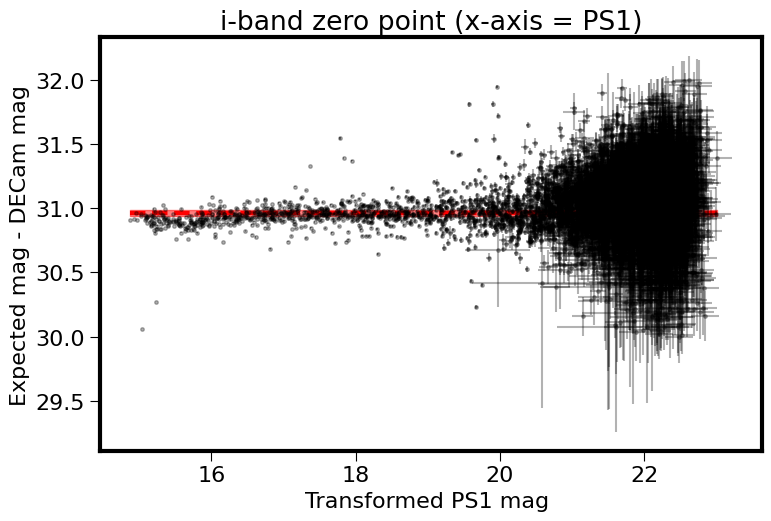


--- z-band ---
z-band: stars selected = 13759
z-band ZP = 30.547 ± 0.009


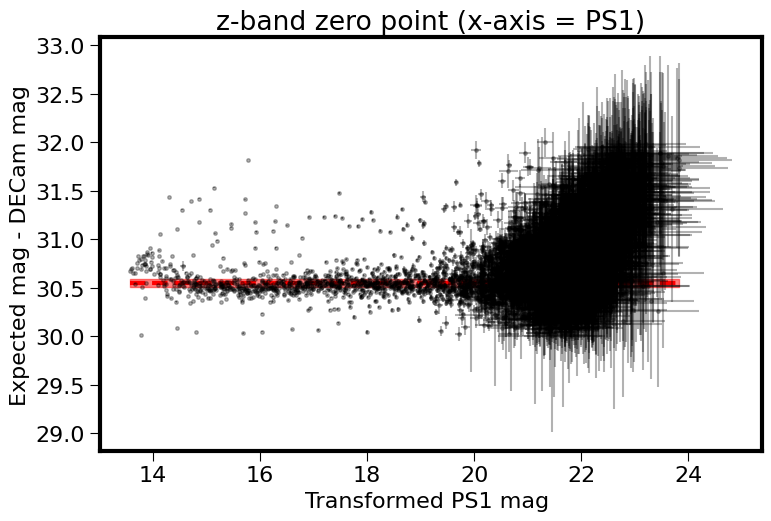

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import ArrayLike

# ---------- Read DECam Catalog ----------
def read_decam_catalog(filename: str) -> pd.DataFrame:
    with open(filename) as f:
        header = f.readline().strip().split(',')
    return pd.read_csv(filename, skiprows=1, names=header)

# ---------- Read Pan-STARRS Catalog ----------
def read_ps_catalog(filename: str) -> pd.DataFrame:
    return pd.read_csv(filename)

# ---------- Star Selection (i-band morphology) ----------
def is_star_ps1(ps_df: pd.DataFrame, band: str = 'i', threshold: float = 0.05) -> ArrayLike:
    psf_col = f"{band}PSFMag"
    kron_col = f"{band}KronMag"
    if psf_col not in ps_df.columns or kron_col not in ps_df.columns:
        raise ValueError(f"Missing columns: {psf_col} or {kron_col}")
    delta_mag = ps_df[psf_col] - ps_df[kron_col]
    return np.abs(delta_mag.values) < threshold

# ---------- Robust PS1 → DECam transforms ----------
def _col(ps: pd.DataFrame, base: str, kind: str = "mag") -> np.ndarray:
    """Get PS1 column robustly. Tries PSFMag and MeanPSFMag variants."""
    if kind == "mag":
        candidates = [f"{base}PSFMag", f"{base}MeanPSFMag"]
    else:
        candidates = [f"{base}PSFMagErr", f"{base}MeanPSFMagErr"]

    for c in candidates:
        if c in ps.columns:
            return ps[c].values.astype(float)

    if kind == "mag":
        raise KeyError(f"No PS1 mag column found for {base}")
    return np.full(len(ps), 0.02, dtype=float)  # default error floor

def convert_panstars_i_dec_mags(ps: pd.DataFrame):
    rPSF = _col(ps, 'r', 'mag'); iPSF = _col(ps, 'i', 'mag')
    rErr = _col(ps, 'r', 'err'); iErr = _col(ps, 'i', 'err')
    i_dec = iPSF - 0.155 * (rPSF - iPSF) + 0.015
    i_dec_err = np.hypot(iErr, 0.155 * np.hypot(iErr, rErr))
    return i_dec, i_dec_err

def convert_panstars_z_dec_mags(ps: pd.DataFrame):
    rPSF = _col(ps, 'r', 'mag'); iPSF = _col(ps, 'i', 'mag'); zPSF = _col(ps, 'z', 'mag')
    rErr = _col(ps, 'r', 'err'); iErr = _col(ps, 'i', 'err'); zErr = _col(ps, 'z', 'err')
    z_dec = zPSF - 0.114 * (rPSF - iPSF) - 0.010
    z_dec_err = np.hypot(zErr, 0.114 * np.hypot(iErr, rErr))
    return z_dec, z_dec_err

# ---------- Straight line model ----------
def straight_line(x_array: np.ndarray, intercept: float):
    return x_array + intercept

# ---------- Pipeline ----------
def prepare_mags(decam_df: pd.DataFrame, ps_df: pd.DataFrame, band: str):
    dec_mags = decam_df['MAG_AUTO'].values.astype(float)
    dec_errs = decam_df['MAGERR_AUTO'].values.astype(float)
    if band == 'i':
        exp_mags, exp_errs = convert_panstars_i_dec_mags(ps_df)
    elif band == 'z':
        exp_mags, exp_errs = convert_panstars_z_dec_mags(ps_df)
    else:
        raise ValueError("band must be 'i' or 'z'.")
    return dec_mags, dec_errs, exp_mags, exp_errs

def apply_broadband_cuts(dec_mags, dec_errs, exp_mags, exp_errs):
    diffs = exp_mags - dec_mags
    diff_cut = np.where((diffs > 30) & (diffs < 32))[0]
    good_values = np.where(exp_mags < 100)[0]
    other_good_values = np.where(dec_mags < -6)[0]
    more_good_values = np.where(exp_errs < 1.0)[0]
    even_more = np.where(dec_errs < 1.0)[0]

    idx = np.intersect1d(good_values, other_good_values)
    idx = np.intersect1d(idx, more_good_values)
    idx = np.intersect1d(idx, diff_cut)
    idx = np.intersect1d(idx, even_more)

    return dec_mags[idx], dec_errs[idx], exp_mags[idx], exp_errs[idx]

def fit_zero_point(dec_mags, exp_mags, exp_errs):
    """Fit ZP as median residual in (-14 < DECam < -11)."""
    fit_sel = np.where((dec_mags > -14) & (dec_mags < -11))[0]
    if len(fit_sel) < 3:
        raise RuntimeError("Not enough points in the fitting range (-14 < DECam < -11) to fit ZP.")
    residuals = exp_mags[fit_sel] - dec_mags[fit_sel]
    zpt = np.median(residuals)
    scatter = np.std(residuals)
    zpt_err = scatter / np.sqrt(len(residuals))
    return zpt, zpt_err

def plot_zpt(dec_mags, dec_errs, exp_mags, exp_errs, band: str, zpt: float, zpt_err: float):
    y = exp_mags - dec_mags
    y_err = np.hypot(dec_errs, exp_errs)
    good = np.where(y_err < 1e5)[0]

    nstd = 5.0
    up = zpt + nstd * zpt_err
    dw = zpt - nstd * zpt_err
    x_fit = np.linspace(np.sort(exp_mags)[0], np.sort(exp_mags)[-1], 200)

    plt.figure(figsize=(8, 5.5))
    plt.errorbar(
        exp_mags[good], y[good],              # <-- PS1 mags on x-axis
        xerr=exp_errs[good], yerr=y_err[good],
        fmt='ko', alpha=0.3, ms=2.5, elinewidth=1.5
    )
    plt.plot(x_fit, zpt * np.ones_like(x_fit), ls='--', color='r', lw=3, zorder=1)
    plt.fill_between(x_fit, up, dw, alpha=.5, color='r')

    plt.xlabel('Transformed PS1 mag ')
    plt.ylabel('Expected mag - DECam mag')
    plt.title(f'{band}-band zero point (x-axis = PS1)')
    plt.tight_layout()
    plt.show()

def run_band(decam_path: str, ps_path: str, band: str):
    decam_df = read_decam_catalog(decam_path)
    ps_df = read_ps_catalog(ps_path)

    # star-like objects
    star_mask = is_star_ps1(ps_df, band='i', threshold=0.05)
    decam_df = decam_df[star_mask].reset_index(drop=True)
    ps_df = ps_df[star_mask].reset_index(drop=True)
    print(f"{band}-band: stars selected = {len(decam_df)}")

    dec_mags, dec_errs, exp_mags, exp_errs = prepare_mags(decam_df, ps_df, band=band)
    dec_mags, dec_errs, exp_mags, exp_errs = apply_broadband_cuts(dec_mags, dec_errs, exp_mags, exp_errs)

    if len(dec_mags) < 3:
        raise RuntimeError(f"After cuts, not enough points to fit for {band}-band.")

    zpt, zpt_err = fit_zero_point(dec_mags, exp_mags, exp_errs)
    print(f"{band}-band ZP = {zpt:.3f} ± {zpt_err:.3f}")

    plot_zpt(dec_mags, dec_errs, exp_mags, exp_errs, band, zpt, zpt_err)
    return zpt, zpt_err

# ---------- Main ----------
if __name__ == "__main__":
    I_DECam = "/Users/aishwarya/Documents/Lyman_alpha/CAT/i_band_decam_matched.cat"
    I_PS    = "/Users/aishwarya/Documents/Lyman_alpha/CAT/i_band_panstarrs_matched.csv"

    Z_DECam = "/Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/z_band_depth_decam_matched.cat"
    Z_PS    = "/Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/z_band_depth_panstarrs_matched.csv"

    print("\n--- i-band ---")
    try:
        run_band(I_DECam, I_PS, band='i')
    except Exception as e:
        print(f"i-band error: {e}")

    print("\n--- z-band ---")
    try:
        run_band(Z_DECam, Z_PS, band='z')
    except Exception as e:
        print(f"z-band error: {e}")


# to save th files  stars only !

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sigmaclip


# -------- Read Catalogs --------
def read_decam_catalog(filename):
    with open(filename) as f:
        header = f.readline().strip().split(',')
    return pd.read_csv(filename, skiprows=1, names=header)

def read_ps_catalog(filename):
    return pd.read_csv(filename)


# -------- Star Selection --------
def is_star_ps1(ps_df, band='z', threshold=0.05):
    """
    Identify stars using PSF - Kron magnitude difference in Pan-STARRS.
    """
    psf_col = f"{band}PSFMag"
    kron_col = f"{band}KronMag"
    if psf_col not in ps_df.columns or kron_col not in ps_df.columns:
        raise ValueError(f"Missing columns: {psf_col} or {kron_col}")
    
    delta_mag = ps_df[psf_col] - ps_df[kron_col]
    return np.abs(delta_mag) < threshold


# -------- PS1 to DECam z-band Transformation --------
def compute_transformed_z(ps_df):
    z_ps1 = ps_df["zPSFMag"]
    r_ps1 = ps_df["rPSFMag"]
    i_ps1 = ps_df["iPSFMag"]
    return z_ps1 - 0.114 * (r_ps1 - i_ps1) - 0.010


# -------- Zero Point Calculation --------
def compute_zero_point(decam_df, ps_df):
    mag_decam = decam_df["MAG_AUTO"].astype(float)
    magerr_decam = decam_df["MAGERR_AUTO"].astype(float)

    mag_ps_transformed = compute_transformed_z(ps_df)

    # Mask bad values
    bad_ps_mask = (
        (ps_df["zPSFMag"] > 100) | (ps_df["rPSFMag"] > 100) | (ps_df["iPSFMag"] > 100) |
        (ps_df["zPSFMag"] < -10) | (ps_df["rPSFMag"] < -10) | (ps_df["iPSFMag"] < -10)
    )
    bad_decam_mask = (mag_decam > 90) | (mag_decam < -10) | ~np.isfinite(mag_decam) | ~np.isfinite(magerr_decam)
    valid = ~bad_ps_mask & ~bad_decam_mask & np.isfinite(mag_ps_transformed)

    mag_decam = mag_decam[valid]
    mag_ps_transformed = mag_ps_transformed[valid]
    delta_mag = mag_decam - mag_ps_transformed

    # Sigma clipping
    clipped, _, _ = sigmaclip(delta_mag, low=3, high=3)
    clipped = clipped[np.isfinite(clipped)]
    zp = np.median(clipped)
    zp_std = np.std(clipped)
    zp_err = zp_std / np.sqrt(len(clipped))

    # Plot
    plt.figure(figsize=(8, 5))
    plt.scatter(mag_ps_transformed, delta_mag, s=10, alpha=0.5, label="Stars")
    plt.axhline(zp, color='g', linestyle='--', label=f'ZP = {zp:.3f} ± {zp_err:.3f}')
    plt.xlabel("Transformed PS1 z (stars only)")
    plt.ylabel("DECam MAG_AUTO - Transformed PS1 z")
    plt.title("Zero Point Calibration (z-band, stars only)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return zp, zp_err


# -------- Run Calibration --------
decam_path = "/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_decam_zdepth_new.cat"
ps_path = "/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_panstars_zdepth_new.csv"

# Read catalogs
decam_df = read_decam_catalog(decam_path)
ps_df = read_ps_catalog(ps_path)

# Star selection
star_mask = is_star_ps1(ps_df, band='z', threshold=0.05)
decam_df = decam_df[star_mask].reset_index(drop=True)
ps_df = ps_df[star_mask].reset_index(drop=True)

# Safety check
if len(decam_df) != len(ps_df):
    print("Warning: Catalog lengths do not match. Ensure row-by-row match.")
else:
    zp, zp_err = compute_zero_point(decam_df, ps_df)
    print(f"ZP (z-band, stars only but the old cat ;)) = {zp:.3f} ± {zp_err:.3f}")


# dr2 

In [ ]:
"""
Program to cross-match SExtractor catalogs with Pan-STARRS DR1
and compute the median angular offset between matched sources.
"""

import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from typing import List, Tuple
from pandas import DataFrame
import os
from glob import glob

### ----------- SExtractor Functions ----------- ###

def _get_column_names(read_line_object: List[str]) -> List[str]:
    """Reads the header info of the SExtractor catalog."""
    header = [line.split()[2] for line in read_line_object if line.startswith('#')]
    return header

def _get_rows(read_line_object: List[str]) -> List[List[float]]:
    """Reads the data rows from the SExtractor catalog."""
    data = [list(map(float, line.split())) for line in read_line_object if not line.startswith('#')]
    return data

def split_names_and_data(read_line_object: List[str]) -> Tuple[List[str], List[List[float]]]:
    """Splits header and data rows."""
    header = _get_column_names(read_line_object)
    data = _get_rows(read_line_object)
    return header, data

def read_cat(sextractor_catalog: str) -> DataFrame:
    """Reads in a SExtractor catalog file and returns a DataFrame."""
    with open(sextractor_catalog, encoding='utf8') as file:
        lines = file.readlines()
    column_names, data = split_names_and_data(lines)
    data_frame = pd.DataFrame(data, columns=column_names)
    return data_frame

### ----------- Cross-match Function ----------- ###

def cross_match(ra_new: np.ndarray, dec_new: np.ndarray, ra_catalog: np.ndarray, dec_catalog: np.ndarray):
    """Cross-match two sets of sky coordinates using astropy."""
    c_new = SkyCoord(ra=ra_new * u.deg, dec=dec_new * u.deg)
    c_catalog = SkyCoord(ra=ra_catalog * u.deg, dec=dec_catalog * u.deg)
    idx, d2d, _ = c_new.match_to_catalog_sky(c_catalog)
    max_separation = 1.0 * u.arcsec
    separation_constraint = d2d < max_separation
    matched_idx_decam = np.where(separation_constraint)[0]
    matched_idx_panstars = idx[separation_constraint]
    return matched_idx_decam, matched_idx_panstars

### ----------- Catalog Matching Class ----------- ###

class CatalogMatcher:
    """Handles matching SExtractor catalogs with Pan-STARRS DR1."""

    def __init__(self, sextractor_cat_path: str, panstarrs_csv_path: str, band: str = 'i'):
        self.sextractor_catalog = read_cat(sextractor_cat_path)
        self.panstarrs_catalog = pd.read_csv(panstarrs_csv_path)
        self.band = band.lower()

    def match_catalogs(self):
        """Cross-match SExtractor and Pan-STARRS DR1 catalogs based on RA/Dec."""
        ra_decam = np.array(self.sextractor_catalog['ALPHAPEAK_J2000'])
        dec_decam = np.array(self.sextractor_catalog['DELTAPEAK_J2000'])

        # Use band-specific RA/Dec
        ra_col = f"{self.band}ra"
        dec_col = f"{self.band}dec"

        # Filter Pan-STARRS to remove bad entries
        pan = self.panstarrs_catalog
        valid = (pan[ra_col] > -999) & (pan[dec_col] > -90) & (pan[dec_col] < 90)
        pan = pan[valid].reset_index(drop=True)

        ra_panstars = np.array(pan[ra_col])
        dec_panstars = np.array(pan[dec_col])

        if len(ra_panstars) == 0 or len(dec_panstars) == 0:
            raise ValueError("Filtered Pan-STARRS catalog has no valid coordinates.")

        idx_decam, idx_panstars = cross_match(ra_decam, dec_decam, ra_panstars, dec_panstars)
        matched_decam = self.sextractor_catalog.iloc[idx_decam].reset_index(drop=True)
        matched_panstars = pan.iloc[idx_panstars].reset_index(drop=True)
        return matched_decam, matched_panstars

    def compute_centroid_offset(self, matched_decam: DataFrame, matched_panstars: DataFrame):
        """Compute and return median RA/Dec offset in arcseconds."""
        ra_decam = matched_decam['ALPHAPEAK_J2000'].values
        dec_decam = matched_decam['DELTAPEAK_J2000'].values
        ra_panstars = matched_panstars[f'{self.band}ra'].values
        dec_panstars = matched_panstars[f'{self.band}dec'].values

        ra_offset_arcsec = (ra_decam - ra_panstars) * 3600.0
        dec_offset_arcsec = (dec_decam - dec_panstars) * 3600.0

        median_ra_offset = np.median(ra_offset_arcsec)
        median_dec_offset = np.median(dec_offset_arcsec)

        print(f"Median RA Offset: {median_ra_offset:.3f} arcsec")
        print(f"Median Dec Offset: {median_dec_offset:.3f} arcsec")
        return median_ra_offset, median_dec_offset

    def apply_offset_correction(self, matched_decam: DataFrame, matched_panstars: DataFrame,
                                 ra_offset: float, dec_offset: float):
        """Apply offset correction and return updated DataFrames with corrected RA/Dec."""
        matched_decam = matched_decam.copy()
        matched_panstars = matched_panstars.copy()

        matched_decam['RA_CORRECTED'] = matched_decam['ALPHAPEAK_J2000'] - (ra_offset / 3600.0)
        matched_decam['DEC_CORRECTED'] = matched_decam['DELTAPEAK_J2000'] - (dec_offset / 3600.0)

        matched_panstars['RA_CORRECTED'] = matched_panstars[f'{self.band}ra'] + (ra_offset / 3600.0)
        matched_panstars['DEC_CORRECTED'] = matched_panstars[f'{self.band}dec'] + (dec_offset / 3600.0)

        return matched_decam, matched_panstars

    def save_matches(self, matched_decam: DataFrame, matched_panstars: DataFrame,
                     decam_out: str, pan_out: str):
        """Save matched catalogs with corrected coordinates to disk."""
        matched_decam.to_csv(decam_out, index=False)
        matched_panstars.to_csv(pan_out, index=False)
        print(f"Saved matched DECam to: {decam_out}")
        print(f"Saved matched Pan-STARRS to: {pan_out}")

### ----------- Main Execution ----------- ###

if __name__ == '__main__':
    # Define directory and Pan-STARRS path
    CAT_DIR = '/Users/aishwarya/Documents/Lyman_alpha/CAT/cat'
    CAT_DIR1 = '/Users/aishwarya/Documents/Lyman_alpha/CAT/dr2'
    PANSTARRS_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/Pannstar_casjobs_dr2.csv'

    # List all .cat files in the directory
    cat_files = glob(os.path.join(CAT_DIR, '*.cat'))

    for cat_file in cat_files:
        base_filename = os.path.splitext(os.path.basename(cat_file))[0]
        print(f"\n--- Processing file: {base_filename} ---")

        try:
            # Create matcher and run cross-match pipeline
            matcher = CatalogMatcher(cat_file, PANSTARRS_PATH, band='i')  # Change to 'z' if needed
            matched_decam, matched_panstars = matcher.match_catalogs()

            if matched_decam.empty or matched_panstars.empty:
                print(f"No matches found for {base_filename}.")
                continue

            # Offset correction
            ra_offset, dec_offset = matcher.compute_centroid_offset(matched_decam, matched_panstars)
            matched_decam_corr, matched_panstars_corr = matcher.apply_offset_correction(
                matched_decam, matched_panstars, ra_offset, dec_offset
            )

            # Save with original file-based names
            decam_out = os.path.join(CAT_DIR1, f'{base_filename}_decam_matched.cat')
            panstarrs_out = os.path.join(CAT_DIR1, f'{base_filename}_panstarrs_matched.csv')
            matcher.save_matches(matched_decam_corr, matched_panstars_corr,
                                 decam_out=decam_out, pan_out=panstarrs_out)
        except Exception as e:
            print(f"Error processing {base_filename}: {e}")


# Color Color Diagram



In [ ]:
import pandas as pd
import numpy as np

def is_star_ps1(df, band='z', threshold=0.05):
    """Return a boolean mask for star-like sources in PS1."""
    psf_col = f'{band}PSFMag'
    kron_col = f'{band}KronMag'
    return (df[psf_col] != -999) & (df[kron_col] != -999) & ((df[psf_col] - df[kron_col]) < threshold)

# ---------- File Paths ----------
input_csv = "/Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/n964_band_panstarrs_matched.csv"
output_csv = "/Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/n964_band_panstarrs_matched_stars_cleaned.csv"

# ---------- Read Data ----------
df = pd.read_csv(input_csv)

# ---------- Remove -999 and bad mags ----------
valid_mag = (df['zPSFMag'] != -999) & (df['yPSFMag'] != -999) & \
            (df['zKronMag'] != -999) & (df['yKronMag'] != -999)

df = df[valid_mag].reset_index(drop=True)

# ---------- Star/Galaxy Cut ----------
z_star_mask = is_star_ps1(df, band='z', threshold=0.05)
y_star_mask = is_star_ps1(df, band='y', threshold=0.05)

# Only keep sources that are star-like in both bands
final_star_mask = z_star_mask & y_star_mask
df_stars = df[final_star_mask].reset_index(drop=True)

# ---------- Save Cleaned File ----------
df_stars.to_csv(output_csv, index=False)
print(f"Saved cleaned stellar Pan-STARRS catalog to: {output_csv}")
print(f"Total stars selected: {len(df_stars)}")


In [ ]:
import numpy as np
import pylab as plt
from scipy import odr
from scipy.stats import gaussian_kde
from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma
import pandas as pd

# ---------- K-Constant Functions ----------
def gaussian(x_array: np.ndarray, mean: float, fwhm: float):
    sig = fwhm * gaussian_fwhm_to_sigma
    return np.exp(-np.power(x_array - mean, 2.) / (2 * np.power(sig, 2.)))

def calculate_k_constant(aperture_radius: float, seeing: float):
    infinite_integral = quad(gaussian, 0, np.inf, args=(0, seeing))
    definite_integral = quad(gaussian, 0, aperture_radius, args=(0, seeing))
    constant = infinite_integral[0] / definite_integral[0]
    return constant

def calculate_k_constant_mag(aperture_radius: float, seeing: float) -> float:
    k_constant = calculate_k_constant(aperture_radius, seeing)
    return -2.5 * np.log10(k_constant)

# ---------- Bottom & Upper Limit Functions ----------
def bottom_limit(x_val):
    m = 1
    c = 28.8
    return m * x_val + c

def upper_limit(x_val):
    m = 1
    c = 29.1
    return m * x_val + c

def is_point_in_limits(x_val: float, y_val: float):
    return bottom_limit(x_val) < y_val < upper_limit(x_val)

def index_in_limits(x_array, y_array):
    return np.array([i for i in range(len(x_array)) if is_point_in_limits(x_array[i], y_array[i])], dtype=int)

# ---------- File Paths ----------
NB964_PANSTARRS = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_panstars_n964depth_new.csv'
NB964_DECam = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_decam_n964depth_new.cat'

# ---------- Constants ----------
MAG_ZEROPOINT = 0.0
NARROW_BAND_SEEING = 1.47
NARROW_BAND_APERTURES = 0.94

# ---------- Load Catalogs ----------
decam = np.genfromtxt(NB964_DECam, delimiter=',', names=True)
pan = pd.read_csv(NB964_PANSTARRS)

# ---------- Extract Photometry and RA/DEC ----------
# Use the columns 'zPSFMag', 'yPSFMag', etc. as well as RA/DEC from the correct columns.
z = pan['zPSFMag'].to_numpy()
y = pan['yPSFMag'].to_numpy()
z_err = pan['zPSFMagErr'].to_numpy()
y_err = pan['yPSFMagErr'].to_numpy()
n964 = decam['MAG_AUTO'] + MAG_ZEROPOINT
n964_err = decam['MAGERR_AUTO']

# Use available RA/DEC columns from Pan-STARRS:
ra = pan['RA_CORRECTED'].to_numpy()
dec = pan['DEC_CORRECTED'].to_numpy()

# ---------- Remove Bad Data: y != -999 ----------
cut = np.where(y != -999)[0]
z, y, n964 = z[cut], y[cut], n964[cut]
z_err, y_err, n964_err = z_err[cut], y_err[cut], n964_err[cut]
ra, dec = ra[cut], dec[cut]

# ---------- Compute Colors and Their Errors ----------
delta_pan = z - y
delta_decam = z - n964
delta_pan_err = np.hypot(z_err, y_err)
delta_decam_err = np.hypot(z_err, n964_err)

# ---------- Apply Color Cuts ----------
cut_x = np.where((delta_pan > -0.2) & (delta_pan < 0.6))[0]
cut_y = np.where((delta_decam > 28.75) & (delta_decam < 29.752))[0]
final_cut = np.intersect1d(cut_x, cut_y)

# ---------- Apply Bottom/Upper Limit Cuts ----------
#fit_cut = index_in_limits(delta_pan[final_cut], delta_decam[final_cut])
delta_pan = delta_pan[final_cut]
delta_decam = delta_decam[final_cut]
delta_pan_err = delta_pan_err[final_cut]
delta_decam_err = delta_decam_err[final_cut]
ra = ra[final_cut]
dec = dec[final_cut]

# ---------- Fit with ODR ----------
def straight_line(params, x):
    alpha, zpt = params
    return alpha * x + zpt

straight_line_model = odr.Model(straight_line)
data = odr.RealData(delta_pan, delta_decam, sx=delta_pan_err, sy=delta_decam_err)
odr_fit = odr.ODR(data, straight_line_model, beta0=[0.81, 28.9])
out = odr_fit.run()
alpha, zpt = out.beta
alpha_err, zpt_err = out.sd_beta

# ---------- K Correction ----------
k_corr = calculate_k_constant_mag(NARROW_BAND_APERTURES, NARROW_BAND_SEEING)
zpt_prime = zpt - k_corr

# ---------- Output ----------
print("Fit Results (1-σ errors):")
print(f"α = {alpha:.3f} ± {alpha_err:.3f}")
print(f"ZPT = {zpt:.3f} ± {zpt_err:.3f}")
print(f"K correction = {k_corr:.3f}")
print(f"ZPT' = {zpt_prime:.3f} ± {zpt_err:.3f}")
print(f"Number of stars used: {len(delta_pan)}")

# ---------- Plot ----------
x_vals = np.linspace(delta_pan.min(), delta_pan.max(), 200)
fit = straight_line([alpha, zpt], x_vals)
fit_upper = straight_line([alpha + alpha_err, zpt + zpt_err], x_vals)
fit_lower = straight_line([alpha - alpha_err, zpt - zpt_err], x_vals)

plt.figure(figsize=(7, 6))
plt.xlabel(r'$z_{\rm PS1} - y_{\rm PS1}$', fontsize=14)
plt.ylabel(r'$z_{\rm PS1} - {\rm NB964}_{\rm inst}$', fontsize=14)

# ---------- KDE Background for Data Visualization ----------
if len(delta_pan) > 10:
    nbins = 100
    kde = gaussian_kde((delta_pan, delta_decam))
    x_i, y_i = np.mgrid[
        delta_pan.min():delta_pan.max():nbins*1j,
        delta_decam.min():delta_decam.max():nbins*1j
    ]
    z_i = kde(np.vstack([x_i.flatten(), y_i.flatten()]))
    plt.pcolormesh(x_i, y_i, z_i.reshape(x_i.shape), shading='auto', cmap='gray_r')

# ---------- Plot Data Points, Fit Line, and 1σ Error Band ----------
plt.scatter(delta_pan, delta_decam, s=25, edgecolor='black', facecolor='cyan', alpha=0.7, label='Data')
plt.plot(x_vals, fit, 'r-', label='Best-fit')
plt.fill_between(x_vals, fit_upper, fit_lower, color='r', alpha=0.3, label=r'1$\sigma$ Fit')
plt.legend()
plt.tight_layout()
plt.savefig('/Users/aishwarya/Documents/Lyman_alpha/CAT/NB964_zpt_cutfit_final.png', dpi=300)
plt.show()


In [ ]:
import numpy as np
import pylab as plt
from scipy.optimize import curve_fit
from scipy.stats import gaussian_kde
from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma
import pandas as pd

# ---------- K-Constant Functions ----------
def gaussian(x_array: np.ndarray, mean: float, fwhm: float):
    sig = fwhm * gaussian_fwhm_to_sigma
    return np.exp(-np.power(x_array - mean, 2.) / (2 * np.power(sig, 2.)))

def calculate_k_constant(aperture_radius: float, seeing: float):
    infinite_integral = quad(gaussian, 0, np.inf, args=(0, seeing))
    definite_integral = quad(gaussian, 0, aperture_radius, args=(0, seeing))
    constant = infinite_integral[0] / definite_integral[0]
    return constant

def calculate_k_constant_mag(aperture_radius: float, seeing: float) -> float:
    k_constant = calculate_k_constant(aperture_radius, seeing)
    return -2.5 * np.log10(k_constant)

# ---------- File Paths ----------
NB964_PANSTARRS = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_panstars_n964depth_new.csv'
NB964_DECam = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_decam_n964depth_new.cat'

# ---------- Constants ----------
MAG_ZEROPOINT = 0.0
NARROW_BAND_SEEING = 1.47
NARROW_BAND_APERTURES = 0.94

# ---------- Load Catalogs ----------
decam = np.genfromtxt(NB964_DECam, delimiter=',', names=True)
pan = pd.read_csv(NB964_PANSTARRS)

# ---------- Extract Photometry and RA/DEC ----------
z = pan['zPSFMag'].to_numpy()
y = pan['yPSFMag'].to_numpy()
z_err = pan['zPSFMagErr'].to_numpy()
y_err = pan['yPSFMagErr'].to_numpy()
n964 = decam['MAG_AUTO'] + MAG_ZEROPOINT
n964_err = decam['MAGERR_AUTO']

ra = pan['RA_CORRECTED'].to_numpy()
dec = pan['DEC_CORRECTED'].to_numpy()

# ---------- Remove Bad Data ----------
cut = np.where(y != -999)[0]
z, y, n964 = z[cut], y[cut], n964[cut]
z_err, y_err, n964_err = z_err[cut], y_err[cut], n964_err[cut]
ra, dec = ra[cut], dec[cut]

# ---------- Compute Colors and Their Errors ----------
delta_pan = z - y
delta_decam = z - n964
delta_pan_err = np.hypot(z_err, y_err)
delta_decam_err = np.hypot(z_err, n964_err)

# ---------- Apply Color Cuts ----------
cut_x = np.where((delta_pan > -0.2) & (delta_pan < 0.6))[0]
cut_y = np.where((delta_decam > 28.75) & (delta_decam < 29.752))[0]
final_cut = np.intersect1d(cut_x, cut_y)

# ---------- Final Data for Fitting ----------
delta_pan = delta_pan[final_cut]
delta_decam = delta_decam[final_cut]
delta_pan_err = delta_pan_err[final_cut]
delta_decam_err = delta_decam_err[final_cut]
ra = ra[final_cut]
dec = dec[final_cut]

# ---------- Define Model ----------
def straight_line(x, alpha, zpt):
    return alpha * x + zpt

# ---------- Run Curve Fit ----------
popt, pcov = curve_fit(straight_line, delta_pan, delta_decam, sigma=delta_decam_err, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))

for val, err in zip(popt, perr):
    print(f"{val:.5f} ± {err:.5f}")

# ----------not  K Correction ----------
k_const = calculate_k_constant_mag(NARROW_BAND_APERTURES, NARROW_BAND_SEEING)
zpt_prime = popt[1] - k_const
print(f"\nK correction: {k_const:.5f}")
print(f"ZPT prime (ZPT - K correction): {zpt_prime:.5f}")

# ---------- Plot ----------
NSTD = 5.0
x_fit = np.linspace(delta_pan.min() - 0.1, delta_pan.max() + 0.1, 200)
fit = straight_line(x_fit, *popt)
fit_up = straight_line(x_fit, *(popt + NSTD * perr))
fit_dw = straight_line(x_fit, *(popt - NSTD * perr))

plt.figure(figsize=(7, 6))
plt.xlabel(r'$z_{\rm PS1} - y_{\rm PS1}$', fontsize=14)
plt.ylabel(r'$z_{\rm PS1} - {\rm NB964}_{\rm inst}$', fontsize=14)

if len(delta_pan) > 10:
    nbins = 100
    kde = gaussian_kde((delta_pan, delta_decam))
    x_i, y_i = np.mgrid[
        delta_pan.min():delta_pan.max():nbins*1j,
        delta_decam.min():delta_decam.max():nbins*1j
    ]
    z_i = kde(np.vstack([x_i.flatten(), y_i.flatten()]))
    plt.pcolormesh(x_i, y_i, z_i.reshape(x_i.shape), shading='auto', cmap='gray_r')

plt.plot(x_fit, fit, 'r-', label='Best-fit')
plt.fill_between(x_fit, fit_dw, fit_up, color='r', alpha=0.3, label=f'{int(NSTD)}$\sigma$ Confidence Band')

plt.legend()
plt.tight_layout()
plt.savefig('/Users/aishwarya/Documents/Lyman_alpha/CAT/NB964_zpt_cutfit_final.png', dpi=300)
plt.show()


In [ ]:
import numpy as np
import pylab as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma
import pandas as pd

# ---------- K-Constant Functions ----------
def gaussian(x_array: np.ndarray, mean: float, fwhm: float):
    sig = fwhm * gaussian_fwhm_to_sigma
    return np.exp(-np.power(x_array - mean, 2.) / (2 * np.power(sig, 2.)))

def calculate_k_constant(aperture_radius: float, seeing: float):
    infinite_integral = quad(gaussian, 0, np.inf, args=(0, seeing))
    definite_integral = quad(gaussian, 0, aperture_radius, args=(0, seeing))
    constant = infinite_integral[0] / definite_integral[0]
    return constant

def calculate_k_constant_mag(aperture_radius: float, seeing: float) -> float:
    k_constant = calculate_k_constant(aperture_radius, seeing)
    return -2.5 * np.log10(k_constant)

# ---------- Linear Model ----------
def straight_line(x, alpha, zpt):
    return alpha * x + zpt

# ---------- Sigma Clipping ----------
def sigma_clip_fit(x, y, yerr, sigma=3.0, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        popt, _ = curve_fit(straight_line, x[mask], y[mask], sigma=yerr[mask], absolute_sigma=True)
        residuals = y - straight_line(x, *popt)
        std = np.std(residuals[mask])
        mask = np.abs(residuals) < sigma * std
    return x[mask], y[mask], yerr[mask], popt

# ---------- File Paths ----------
NB964_PANSTARRS = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_panstars_n964depth_new.csv'
NB964_DECam = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_decam_n964depth_new.cat'

# ---------- Constants ----------
MAG_ZEROPOINT = 0.0
NARROW_BAND_SEEING = 1.47
NARROW_BAND_APERTURES = 0.94
MIN_ERR = 0.01

# ---------- Load Catalogs ----------
decam = np.genfromtxt(NB964_DECam, delimiter=',', names=True)
pan = pd.read_csv(NB964_PANSTARRS)

# ---------- Extract Photometry ----------
z = pan['zPSFMag'].to_numpy()
y = pan['yPSFMag'].to_numpy()
z_err = pan['zPSFMagErr'].to_numpy()
y_err = pan['yPSFMagErr'].to_numpy()
n964 = decam['MAG_AUTO'] + MAG_ZEROPOINT
n964_err = decam['MAGERR_AUTO']

# ---------- Remove Bad Data ----------
cut = np.where(y != -999)[0]
z, y, n964 = z[cut], y[cut], n964[cut]
z_err, y_err, n964_err = z_err[cut], y_err[cut], n964_err[cut]

# ---------- Compute Colors and Errors ----------
delta_pan = z - y
delta_decam = z - n964
delta_pan_err = np.hypot(z_err, y_err)
delta_decam_err = np.hypot(z_err, n964_err)

# ---------- Apply Color Cuts ----------
cut_x = np.where((delta_pan > -0.2) & (delta_pan < 0.6))[0]
cut_y = np.where((delta_decam > 28.75) & (delta_decam < 29.752))[0]
final_cut = np.intersect1d(cut_x, cut_y)

# ---------- Final Sample ----------
delta_pan = delta_pan[final_cut]
delta_decam = delta_decam[final_cut]
delta_pan_err = delta_pan_err[final_cut]
delta_decam_err = delta_decam_err[final_cut]
delta_decam_err = np.clip(delta_decam_err, MIN_ERR, None)

# ---------- 3-Sigma Clipping + Fit ----------
delta_pan_clipped, delta_decam_clipped, delta_decam_err_clipped, _ = sigma_clip_fit(
    delta_pan, delta_decam, delta_decam_err, sigma=5.0
)

# ---------- Final Linear Fit ----------
popt, pcov = curve_fit(
    straight_line,
    delta_pan_clipped,
    delta_decam_clipped,
    sigma=delta_decam_err_clipped,
    absolute_sigma=True
)
perr = np.sqrt(np.diag(pcov))

# ---------- Print Fit Results ----------
print(f"Slope (alpha):     {popt[0]:.5f} ± {perr[0]:.5f}")
print(f"Intercept (zpt):   {popt[1]:.5f} ± {perr[1]:.5f}")

# ---------- K-Correction ----------
k_const = calculate_k_constant_mag(NARROW_BAND_APERTURES, NARROW_BAND_SEEING)
zpt_prime = popt[1] - k_const
print(f"\nK correction:      {k_const:.5f}")
print(f"ZPT prime:         {zpt_prime:.5f}")

# ---------- Compute Fit & Bands ----------
x_fit = np.linspace(delta_pan_clipped.min() - 0.1, delta_pan_clipped.max() + 0.1, 200)
fit = straight_line(x_fit, *popt)



# ---------- Plot ----------
plt.figure(figsize=(7, 6))
plt.xlabel(r'$z_{\rm PS1} - y_{\rm PS1}$', fontsize=14)
plt.ylabel(r'$z_{\rm PS1} - {\rm NB964}_{\rm inst}$', fontsize=14)



# Best Fit Line
plt.plot(x_fit, fit, 'r-', label='Best-fit', zorder=3)

# Data Points
plt.errorbar(delta_pan_clipped, delta_decam_clipped, yerr=delta_decam_err_clipped,
             fmt='o', alpha=0.3, label='Clipped Data', zorder=4)

plt.ylim(28.5, 30.0)
plt.legend()
plt.tight_layout()
# plt.savefig('/Users/aishwarya/Documents/Lyman_alpha/CAT/NB964_zpt_cutfit_conf_scatter.png', dpi=300)
plt.show()


In [ ]:
import numpy as np
import pylab as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma
import pandas as pd

# ---------- K-Constant Functions ----------
def gaussian(x_array: np.ndarray, mean: float, fwhm: float):
    sig = fwhm * gaussian_fwhm_to_sigma
    return np.exp(-np.power(x_array - mean, 2.) / (2 * np.power(sig, 2.)))

def calculate_k_constant(aperture_radius: float, seeing: float):
    infinite_integral = quad(gaussian, 0, np.inf, args=(0, seeing))
    definite_integral = quad(gaussian, 0, aperture_radius, args=(0, seeing))
    constant = infinite_integral[0] / definite_integral[0]
    return constant

def calculate_k_constant_mag(aperture_radius: float, seeing: float) -> float:
    k_constant = calculate_k_constant(aperture_radius, seeing)
    return -2.5 * np.log10(k_constant)

# ---------- Linear Model ----------
def straight_line(x, alpha, zpt):
    return alpha * x + zpt

# ---------- Sigma Clipping Fit ----------
def sigma_clip_fit(x, y, yerr, sigma=5.0, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        popt, _ = curve_fit(straight_line, x[mask], y[mask], sigma=yerr[mask], absolute_sigma=True)
        residuals = y - straight_line(x, *popt)
        std = np.std(residuals[mask])
        mask = np.abs(residuals) < sigma * std
    return x[mask], y[mask], yerr[mask], popt

# ---------- File Paths ----------
NB964_PANSTARRS = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_panstars_n964depth_new.csv'
NB964_DECam = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_decam_n964depth_new.cat'

# ---------- Constants ----------
MAG_ZEROPOINT = 0.0
NARROW_BAND_SEEING = 1.47
NARROW_BAND_APERTURES = 0.94
MIN_ERR = 0.01
NSTD = 3  # For confidence band

# ---------- Load Catalogs ----------
decam = np.genfromtxt(NB964_DECam, delimiter=',', names=True)

# ---------- Star Selection ----------
decam = decam[decam['MAG_AUTO'] < 3]  # Select bright stars only

pan = pd.read_csv(NB964_PANSTARRS)

# ---------- Extract Photometry ----------
z = pan['zPSFMag'].to_numpy()
y = pan['yPSFMag'].to_numpy()
z_err = pan['zPSFMagErr'].to_numpy()
y_err = pan['yPSFMagErr'].to_numpy()

n964 = decam['MAG_AUTO'] + MAG_ZEROPOINT
n964_err = decam['MAGERR_AUTO']

# ---------- Synchronize catalog lengths and mask ----------
# This assumes both catalogs are aligned entry-wise (same ordering, matched beforehand)
# If catalogs are not aligned, a proper cross-match is needed.

# Mask invalid Pan-STARRS data
valid = (y != -999)

# Apply valid mask to Pan-STARRS arrays
z = z[valid]
y = y[valid]
z_err = z_err[valid]
y_err = y_err[valid]

# Apply the same mask to DECam arrays (must have same length!)
n964 = n964[valid]
n964_err = n964_err[valid]

# ---------- Compute Colors and Errors ----------
delta_pan = z - y
delta_decam = z - n964
delta_pan_err = np.hypot(z_err, y_err)
delta_decam_err = np.hypot(z_err, n964_err)

# ---------- Apply Color Cuts ----------
cut_x = np.where((delta_pan > -0.2) & (delta_pan < 0.6))[0]
cut_y = np.where((delta_decam > 28.75) & (delta_decam < 29.752))[0]
final_cut = np.intersect1d(cut_x, cut_y)

# ---------- Final Sample ----------
delta_pan = delta_pan[final_cut]
delta_decam = delta_decam[final_cut]
delta_pan_err = delta_pan_err[final_cut]
delta_decam_err = delta_decam_err[final_cut]
delta_decam_err = np.clip(delta_decam_err, MIN_ERR, None)

# ---------- 3-Sigma Clipping + Fit ----------
delta_pan_clipped, delta_decam_clipped, delta_decam_err_clipped, _ = sigma_clip_fit(
    delta_pan, delta_decam, delta_decam_err, sigma=3.0
)

# ---------- Final Linear Fit ----------
popt, pcov = curve_fit(
    straight_line,
    delta_pan_clipped,
    delta_decam_clipped,
    sigma=delta_decam_err_clipped,
    absolute_sigma=True
)
perr = np.sqrt(np.diag(pcov))

# ---------- Print Fit Results ----------
print(f"Slope (alpha):     {popt[0]:.5f} ± {perr[0]:.5f}")
print(f"Intercept (zpt):   {popt[1]:.5f} ± {perr[1]:.5f}")

# ---------- K-Correction ----------
k_const = calculate_k_constant_mag(NARROW_BAND_APERTURES, NARROW_BAND_SEEING)
zpt_prime = popt[1] - k_const
print(f"\nK correction:      {k_const:.5f}")
print(f"ZPT prime:         {zpt_prime:.5f}")

# ---------- Compute Fit & Confidence Band ----------
x_fit = np.linspace(delta_pan_clipped.min() - 0.1, delta_pan_clipped.max() + 0.1, 1000)
fit = straight_line(x_fit, *popt)

# Error band from Jacobian + covariance
J = np.vstack([x_fit, np.ones_like(x_fit)]).T
fit_err = np.sqrt(np.sum((J @ pcov) * J, axis=1))

fit_up = fit + NSTD * fit_err
fit_dw = fit - NSTD * fit_err

# ---------- Plot ----------
plt.figure(figsize=(7, 6))
plt.xlabel(r'$z_{\rm PS1} - y_{\rm PS1}$', fontsize=14)
plt.ylabel(r'$z_{\rm PS1} - {\rm NB964}_{\rm inst}$', fontsize=14)

plt.plot(x_fit, fit, 'r-', label='Best-fit', zorder=3)
plt.fill_between(x_fit, fit_dw, fit_up, color='gray', alpha=0.3, label=f'±{NSTD}σ Band', zorder=2)
print(len(delta_pan_clipped ))

plt.errorbar(delta_pan_clipped, delta_decam_clipped, yerr=delta_decam_err_clipped,
             fmt='o', alpha=0.3, label='Clipped Data', zorder=4)

plt.xlim(-0.3, 0.7)
plt.ylim(28.5, 30.0)
plt.legend()
plt.tight_layout()
# plt.savefig('/Users/aishwarya/Documents/Lyman_alpha/CAT/NB964_zpt_fit_band.png', dpi=300)
plt.show()


In [ ]:
import numpy as np
import pylab as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma
import pandas as pd

# ---------- K-Constant Functions ----------
def gaussian(x_array: np.ndarray, mean: float, fwhm: float):
    sig = fwhm * gaussian_fwhm_to_sigma
    return np.exp(-np.power(x_array - mean, 2.) / (2 * np.power(sig, 2.)))

def calculate_k_constant(aperture_radius: float, seeing: float):
    infinite_integral = quad(gaussian, 0, np.inf, args=(0, seeing))
    definite_integral = quad(gaussian, 0, aperture_radius, args=(0, seeing))
    constant = infinite_integral[0] / definite_integral[0]
    return constant

def calculate_k_constant_mag(aperture_radius: float, seeing: float) -> float:
    k_constant = calculate_k_constant(aperture_radius, seeing)
    return -2.5 * np.log10(k_constant)

# ---------- Linear Model ----------
def straight_line(x, alpha, zpt):
    return alpha * x + zpt

# ---------- Sigma Clipping Fit ----------
def sigma_clip_fit(x, y, yerr, sigma=3.0, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        popt, _ = curve_fit(straight_line, x[mask], y[mask], sigma=yerr[mask], absolute_sigma=True)
        residuals = y - straight_line(x, *popt)
        std = np.std(residuals[mask])
        mask = np.abs(residuals) < sigma * std
    return x[mask], y[mask], yerr[mask], popt

# ---------- File Paths ----------

# ---------- File Paths ----------
decam_out='/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_decam_n964depth_new.cat'
pan_out='/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_panstars_n964depth_new.csv'
     

# ---------- Constants ----------
MAG_ZEROPOINT = 0.0
NARROW_BAND_SEEING = 1.47
NARROW_BAND_APERTURES = 0.94
MIN_ERR = 0.01
NSTD = 5  # sigma level for confidence band

# ---------- Load Catalogs ----------
decam = pd.read_csv(decam_out)  
pan = pd.read_csv(pan_out)

# ---------- Extract Photometry ----------
z = pan['zPSFMag'].to_numpy()
y = pan['yPSFMag'].to_numpy()
z_err = pan['zPSFMagErr'].to_numpy()
y_err = pan['yPSFMagErr'].to_numpy()

n964 = decam['MAG_AUTO'].to_numpy() + MAG_ZEROPOINT
n964_err = decam['MAGERR_AUTO'].to_numpy()

# ---------- Remove Bad Data ----------
valid = (y != -999)
z, y, n964 = z[valid], y[valid], n964[valid]
z_err, y_err, n964_err = z_err[valid], y_err[valid], n964_err[valid]

# ---------- Compute Colors and Errors ----------
delta_pan = z - y
delta_decam = z - n964
delta_pan_err = np.hypot(z_err, y_err)
delta_decam_err = np.hypot(z_err, n964_err)

# ---------- Apply Color Cuts ----------
cut_x = np.where((delta_pan > -0.2) & (delta_pan < 0.6))[0]
cut_y = np.where((delta_decam > 28.75) & (delta_decam < 29.752))[0]
final_cut = np.intersect1d(cut_x, cut_y)

# ---------- Final Sample ----------
delta_pan = delta_pan[final_cut]
delta_decam = delta_decam[final_cut]
delta_pan_err = delta_pan_err[final_cut]
delta_decam_err = delta_decam_err[final_cut]
delta_decam_err = np.clip(delta_decam_err, MIN_ERR, None)

# ---------- 3-Sigma Clipping + Fit ----------
delta_pan_clipped, delta_decam_clipped, delta_decam_err_clipped, _ = sigma_clip_fit(
    delta_pan, delta_decam, delta_decam_err, sigma=3.0
)

# ---------- Final Linear Fit on Clipped Data ----------
popt, pcov = curve_fit(
    straight_line,
    delta_pan_clipped,
    delta_decam_clipped,
    sigma=delta_decam_err_clipped,
    absolute_sigma=True
)
perr = np.sqrt(np.diag(pcov))

# ---------- Print Fit Results ----------
print(f"Slope (alpha):     {popt[0]:.5f} ± {perr[0]:.5f}")
print(f"Intercept (zpt):   {popt[1]:.5f} ± {perr[1]:.5f}")

# ---------- K-Correction ----------
k_const = calculate_k_constant_mag(NARROW_BAND_APERTURES, NARROW_BAND_SEEING)
zpt_prime = popt[1] - k_const
print(f"\nK correction:      {k_const:.5f}")
print(f"ZPT prime:         {zpt_prime:.5f}")

# ---------- Compute Fit & Confidence Band over data range ----------
x_fit = np.linspace(delta_pan_clipped.min(), delta_pan_clipped.max(), 200)
fit = straight_line(x_fit, *popt)

# Error from parameter covariance
#J = np.vstack([x_fit, np.ones_like(x_fit)]).T
#fit_err_param = np.sqrt(np.sum((J @ pcov) * J, axis=1))

# Intrinsic scatter from residuals
residuals = delta_decam_clipped - straight_line(delta_pan_clipped, *popt)
scatter_rms = np.std(residuals)

# Total uncertainty (param + intrinsic scatter)
#fit_err_total = np.sqrt(fit_err_param**2 + scatter_rms**2)
#fit_up = fit + NSTD * fit_err_total
#fit_dw = fit - NSTD * fit_err_total
print(len(delta_pan_clipped), len(fit), len(fit_up), len(fit_dw))
# ---------- Plot ----------
plt.figure(figsize=(7, 6))
plt.xlabel(r'$z_{\rm PS1} - y_{\rm PS1}$', fontsize=14)
plt.ylabel(r'$z_{\rm PS1} - {\rm NB964}_{\rm inst}$', fontsize=14)

plt.plot(x_fit, fit, 'r-', label='Best-fit', zorder=3)
#plt.fill_between(x_fit, fit_dw, fit_up, color='gray', alpha=0.3, label=f'±{NSTD}σ Band', zorder=2)

plt.errorbar(delta_pan_clipped, delta_decam_clipped, yerr=delta_decam_err_clipped,
             fmt='o', alpha=0.3, label='Clipped Data', zorder=4)

plt.xlim(delta_pan_clipped.min() - 0.05, delta_pan_clipped.max() + 0.05)
plt.ylim(delta_decam_clipped.min() - 0.1, delta_decam_clipped.max() + 0.1)
plt.ylim(28.5, 30.0)

plt.legend()
plt.tight_layout()
# plt.savefig('/Users/aishwarya/Documents/Lyman_alpha/CAT/NB964_zpt_fit_band.png', dpi=300)
plt.show()


In [ ]:
import numpy as np
import pylab as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

# ---------- K-Constant Functions ----------
def gaussian(x_array: np.ndarray, mean: float, fwhm: float):
    sig = fwhm * gaussian_fwhm_to_sigma
    return np.exp(-np.power(x_array - mean, 2.) / (2 * np.power(sig, 2.)))

def calculate_k_constant(aperture_radius: float, seeing: float):
    infinite_integral = quad(gaussian, 0, np.inf, args=(0, seeing))
    definite_integral = quad(gaussian, 0, aperture_radius, args=(0, seeing))
    constant = infinite_integral[0] / definite_integral[0]
    return constant

def calculate_k_constant_mag(aperture_radius: float, seeing: float) -> float:
    k_constant = calculate_k_constant(aperture_radius, seeing)
    return -2.5 * np.log10(k_constant)

# ---------- Linear Model ----------
def straight_line(x, alpha, zpt):
    return alpha * x + zpt

# ---------- Sigma Clipping Fit ----------
def sigma_clip_fit(x, y, yerr, sigma=5.0, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        popt, _ = curve_fit(straight_line, x[mask], y[mask], sigma=yerr[mask], absolute_sigma=True)
        residuals = y - straight_line(x, *popt)
        std = np.std(residuals[mask])
        mask = np.abs(residuals) < sigma * std
    return x[mask], y[mask], yerr[mask], popt

# ---------- Star selection in Pan-STARRS ----------
def is_star_ps1(ps_df, band='i', threshold=0.05):
    psf_col = f"{band}PSFMag"
    kron_col = f"{band}KronMag"
    if psf_col not in ps_df.columns or kron_col not in ps_df.columns:
        raise ValueError(f"Missing columns: {psf_col} or {kron_col}")
    delta_mag = ps_df[psf_col] - ps_df[kron_col]
    return np.abs(delta_mag) < threshold

# ---------- File Paths ----------
NB964_PANSTARRS = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_panstars_n964depth_new.csv'
NB964_DECam = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_decam_n964depth_new.cat'

# ---------- Constants ----------
MAG_ZEROPOINT = 0.0
NARROW_BAND_SEEING = 1.47
NARROW_BAND_APERTURES = 0.94
MIN_ERR = 0.01
NSTD = 3  # Confidence band sigma
MAX_MATCH_SEP_ARCSEC = 2.0  # Maximum matching separation

# ---------- Load catalogs ----------
decam = np.genfromtxt(NB964_DECam, delimiter=',', names=True)
pan = pd.read_csv(NB964_PANSTARRS)

# ---------- Select bright stars in DECam ----------
decam_stars_mask = decam['MAG_AUTO'] < 3
decam_stars = decam[decam_stars_mask]

# ---------- Select stars in Pan-STARRS ----------
pan_star_mask = is_star_ps1(pan, band='i', threshold=0.05)
pan_stars = pan[pan_star_mask].copy()

# ---------- Clean Pan-STARRS positions ----------
pan_stars['ira'] = pd.to_numeric(pan_stars['ira'], errors='coerce')
pan_stars['idec'] = pd.to_numeric(pan_stars['idec'], errors='coerce')
pan_stars = pan_stars.dropna(subset=['ira', 'idec']).reset_index(drop=True)

# ---------- Cross-match DECam and Pan-STARRS ----------
coords_decam = SkyCoord(ra=decam_stars['ALPHAPEAK_J2000'] * u.deg, dec=decam_stars['DELTAPEAK_J2000'] * u.deg)
coords_pan = SkyCoord(ra=pan_stars['ira'] * u.deg, dec=pan_stars['idec'] * u.deg)

idx, d2d, _ = coords_decam.match_to_catalog_sky(coords_pan)
match_mask = d2d < MAX_MATCH_SEP_ARCSEC * u.arcsec

decam_matched = decam_stars[match_mask]
pan_matched = pan_stars.iloc[idx[match_mask]].reset_index(drop=True)

# ---------- Extract magnitudes and errors ----------
n964 = decam_matched['MAG_AUTO'] + MAG_ZEROPOINT
n964_err = decam_matched['MAGERR_AUTO']

z = pan_matched['zPSFMag'].values
y = pan_matched['yPSFMag'].values
z_err = pan_matched['zPSFMagErr'].values
y_err = pan_matched['yPSFMagErr'].values

# ---------- Mask invalid mags in Pan-STARRS ----------
valid = (y != -999) & (z != -999)
n964 = n964[valid]
n964_err = n964_err[valid]
z = z[valid]
y = y[valid]
z_err = z_err[valid]
y_err = y_err[valid]

# ---------- Compute colors and errors ----------
delta_pan = z - y
delta_decam = z - n964
delta_pan_err = np.hypot(z_err, y_err)
delta_decam_err = np.hypot(z_err, n964_err)

# ---------- Apply color cuts ----------
cut_x = np.where((delta_pan > -0.2) & (delta_pan < 0.6))[0]
cut_y = np.where((delta_decam > 28.75) & (delta_decam < 29.752))[0]
final_cut = np.intersect1d(cut_x, cut_y)

delta_pan = delta_pan[final_cut]
delta_decam = delta_decam[final_cut]
delta_pan_err = delta_pan_err[final_cut]
delta_decam_err = delta_decam_err[final_cut]
delta_decam_err = np.clip(delta_decam_err, MIN_ERR, None)

# ---------- Sigma clipping + linear fit ----------
delta_pan_clipped, delta_decam_clipped, delta_decam_err_clipped, _ = sigma_clip_fit(
    delta_pan, delta_decam, delta_decam_err, sigma=3.0
)

popt, pcov = curve_fit(
    straight_line,
    delta_pan_clipped,
    delta_decam_clipped,
    sigma=delta_decam_err_clipped,
    absolute_sigma=True
)
perr = np.sqrt(np.diag(pcov))

print(f"Slope (alpha):     {popt[0]:.5f} ± {perr[0]:.5f}")
print(f"Intercept (zpt):   {popt[1]:.5f} ± {perr[1]:.5f}")

# ---------- K-correction ----------
k_const = calculate_k_constant_mag(NARROW_BAND_APERTURES, NARROW_BAND_SEEING)
zpt_prime = popt[1] - k_const
print(f"\nK correction:      {k_const:.5f}")
print(f"ZPT prime:         {zpt_prime:.5f}")

# ---------- Plot fit and confidence band ----------
x_fit = np.linspace(delta_pan_clipped.min() - 0.1, delta_pan_clipped.max() + 0.1, 1000)
fit = straight_line(x_fit, *popt)

J = np.vstack([x_fit, np.ones_like(x_fit)]).T
fit_err = np.sqrt(np.sum((J @ pcov) * J, axis=1))

fit_up = fit + NSTD * fit_err
fit_dw = fit - NSTD * fit_err

plt.figure(figsize=(7, 6))
plt.xlabel(r'$z_{\rm PS1} - y_{\rm PS1}$', fontsize=14)
plt.ylabel(r'$z_{\rm PS1} - {\rm NB964}_{\rm inst}$', fontsize=14)
plt.plot(x_fit, fit, 'r-', label='Best-fit', zorder=3)
plt.fill_between(x_fit, fit_dw, fit_up, color='gray', alpha=0.3, label=f'±{NSTD}σ Band', zorder=2)
plt.errorbar(delta_pan_clipped, delta_decam_clipped, yerr=delta_decam_err_clipped,
             fmt='o', alpha=0.3, label='Clipped Data', zorder=4)
plt.xlim(-0.3, 0.7)
plt.ylim(28.5, 30.0)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
from astropy.coordinates import SkyCoord
import astropy.units as u

# ---------- Object Coordinates in sexagesimal ----------
obj_coords = {
    'QSO': ('23:48:33.33', '-30:54:10.23'),
    'LAE-1': ('23:50:39.46', '-31:47:26.41'),
    'LAE-2': ('23:49:25.39', '-31:46:34.95'),
    'LAE-3': ('23:49:45.53', '-31:39:01.46'),
    'LAE-4': ('23:48:22.23', '-31:37:53.92'),
    'LAE-5': ('23:48:17.08', '-31:30:18.94'),
    'LAE-6': ('23:46:51.65', '-31:19:29.93'),
    'LAE-7': ('23:52:04.95', '-31:16:20.60'),
    'LAE-8': ('23:44:51.34', '-31:14:01.78'),
    'LAE-9': ('23:49:09.11', '-31:11:23.68'),
    'LAE-10': ('23:48:38.18', '-31:10:25.49'),
    'LAE-11': ('23:52:11.44', '-31:10:09.82'),
    'LAE-12': ('23:50:09.67', '-31:00:28.43'),
    'LAE-13': ('23:52:50.08', '-30:59:23.05'),
    'LAE-14': ('23:46:52.33', '-30:57:07.02'),
    'LAE-15': ('23:52:39.27', '-30:51:50.73'),
    'LAE-16': ('23:51:42.32', '-30:50:46.97'),
    'LAE-17': ('23:45:30.76', '-30:50:42.20'),
    'LAE-18': ('23:45:38.56', '-30:41:06.23'),
    'LAE-19': ('23:50:56.96', '-30:40:16.95'),
    'LAE-20': ('23:46:20.25', '-30:40:03.94'),
    'LAE-21': ('23:48:12.27', '-30:32:34.32'),
    'LAE-22': ('23:44:45.07', '-30:31:07.12'),
    'LAE-23': ('23:47:37.50', '-30:28:28.35'),
    'LAE-24': ('23:44:31.64', '-30:27:35.79'),
    'LAE-25': ('23:47:38.55', '-30:25:47.75'),
    'LAE-26': ('23:44:36.91', '-30:25:04.43'),
    'LAE-27': ('23:48:21.02', '-30:24:04.19'),
    'LAE-28': ('23:47:21.19', '-30:22:53.54'),
    'LAE-29': ('23:46:27.28', '-30:21:51.57'),
    'LAE-30': ('23:49:27.05', '-30:21:25.98'),
    'LAE-31': ('23:50:27.20', '-30:21:13.39'),
    'LAE-32': ('23:45:02.91', '-30:12:32.87'),
    'LAE-33': ('23:49:34.65', '-30:12:40.49'),
    'LAE-34': ('23:50:23.24', '-30:10:45.41'),
    'LAE-35': ('23:50:45.07', '-30:05:13.35'),
    'LAE-36': ('23:49:43.48', '-30:03:01.26'),
    'LAE-37': ('23:50:36.54', '-30:01:46.79'),
    'LAE-38': ('23:48:43.58', '-29:53:13.94'),
}

# ---------- Convert and Save to TXT ----------
output_lines = []

for name, (ra_str, dec_str) in obj_coords.items():
    coord = SkyCoord(ra=ra_str, dec=dec_str, unit=(u.hourangle, u.deg))
    output_lines.append(f"{coord.ra.deg:.7f} {coord.dec.deg:.7f}")

# Save to file
with open("/Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/object_coords_deg.txt", "w") as f:
    f.write("\n".join(output_lines))

print("Saved decimal RA/Dec to 'object_coords_deg.txt'")
